## Application of Machine Learning Techniques in Customer Churn Prediction for Telecommunication Industries


**Author:** Adeline Makokha  
**Adm No:** 191199  
**Course:** Dissertation


### Abstract
This study develops a machine learning pipeline for identifying customers at risk of service discontinuation within a telecommunications environment. Using a proprietary dataset comprising business accounts, the analysis proceeds through structured phases: loading the data, exploratory profiling, preprocessing, class-imbalance mitigation, comparative model evaluation, and model-agnostic explainability. The selected classifier was an EasyEnsembleClassifier trained after SVMSMOTE resampling which achieved a recall of 38.2 % on the minority (churner) class, demonstrating that ensemble-based imbalanced learning outperforms single-model baselines under severe class skew. Findings are operationalised through a FastAPI deployment that surfaces risk scores and recommended retention actions via an interactive dashboard.




### 1.1 Background

Voluntary service termination which is commonly termed *churn* poses a structural challenge for telecommunications providers operating in saturated, price-competitive markets. Unlike involuntary attrition triggered by non-payment, voluntary churn reflects deliberate customer agency and is therefore foreseeable if behavioural signals are monitored proactively. Annual churn rates across the global telecommunications sector routinely exceed 30 percent, implying that a typical mid-size operator loses nearly one third of its subscriber base each year. Because acquiring a new customer costs between five and seven times more than retaining an existing one, even a modest improvement in retention rate translates into measurable gains.

Business segments that is Small and Medium Enterprises (SMEs), Small Office Home Office (SOHO) accounts, and Very Small Enterprises (VSEs), exhibit churn dynamics distinct from consumer segments. Corporate accounts generate higher average revenue per user (ARPU), maintain multiple subscriber lines, and negotiate service-level agreements. Their departure therefore produces a disproportionate revenue impact. Despite this, the published literature concentrates overwhelmingly on individual consumer churn, leaving a methodological gap for business-segment modelling.

### 1.2 Problem Statement

Existing retention systems in many operators are reactive: account managers are notified of churn *after* the customer has already initiated a port-out request or withheld renewal. Root causes include reliance on rule-based triggers (e.g., payment delay exceeding N days), absence of probabilistic risk scoring, and siloed data that do not integrate subscriber-level metrics with account-level revenue trajectories.

A forward-looking predictive system must overcome three technical obstacles common to telecommunications datasets:

1. **Severe class imbalance** — churners typically constitute fewer than 10 % of observations, causing standard classifiers to collapse to the majority class.
2. **Mixed feature types** — categorical identifiers (value segment, geographic zone, account manager) coexist with continuous revenue and subscriber-count variables requiring different preprocessing treatments.
3. **Low signal-to-noise ratio** — many features correlate weakly with churn in isolation; predictive power emerges from engineered interaction terms and ensemble aggregation.

### 1.3 Research Objectives

**Main Objective:** Construct and evaluate a machine learning framework that quantifies churn risk for business telecommunications customers and integrates predictive outputs into a decision-support interface.

**Specific Objectives:**

i. Perform systematic exploratory data analysis to characterise distributional properties, class imbalance magnitude, and inter-variable relationships.


ii. Compare multiple class-imbalance mitigation strategies (SMOTE, ADASYN, SVMSMOTE, BorderlineSMOTE, SMOTETomek) and select the technique that maximises minority-class recall on a held-out validation partition.

iii. Train, cross-validate, and rank seven classifier families using metrics appropriate for imbalanced binary classification: F1-score, Precision-Recall Area Under the Curve (PR-AUC), Matthews Correlation Coefficient (MCC), and Recall.

iv. Apply post-hoc explainability methods (Permutation Feature Importance, SHAP, LIME) to identify the behavioural drivers most predictive of churn.

v. Serialise the selected model and expose it through a RESTful API with a front-end dashboard, enabling real-time risk scoring and retention campaign management.

### 1.4 Significance

Accurate churn prediction generates value across three organisational layers:

- **Strategic:** Revenue-at-risk quantification supports capital allocation and retention budget planning.
- **Operational:** Risk scores prioritise account manager workloads toward highest-impact interventions.
- **Analytical:** Feature importance rankings reveal which service dimensions drive dissatisfaction, informing product and pricing decisions.

Beyond the firm, reducing churn in the business segment stabilises digital infrastructure for SMEs that depend on reliable connectivity for e-commerce, remote work, and financial transactions—a socio-economic consideration of particular relevance in emerging markets.



### 2. Dataset Description

The dataset contains 8,453 business customer accounts extracted from a telecommunications operator's CRM and billing systems. Each record represents a unique account (PID) observed over a 24-month behavioural window. The binary target variable `CHURN` (Yes / No) is derived from service termination events logged in the operational support system.

| Variable | Type | Description |
|---|---|---|
| `PID` | String | Unique account identifier |
| `CRM_PID_Value_Segment` | Categorical | Operator-assigned tier: *High Value*, *Medium Value*, *Low Value* |
| `EffectiveSegment` | Categorical | Business classification: *SME*, *SOHO*, *VSE* |
| `Billing_ZIP` | Integer | Geographic billing zone code |
| `KA_name` | Categorical | Assigned key account manager |
| `Active_subscribers` | Integer | Count of lines in active billing state |
| `Not_Active_subscribers` | Float | Count of lines in inactive state |
| `Suspended_subscribers` | Float | Lines suspended within the reference period |
| `Total_SUBs` | Integer | Total lines under the account |
| `AvgMobileRevenue` | Float | Mean monthly mobile-service revenue |
| `AvgFIXRevenue` | Float | Mean monthly fixed-line revenue |
| `TotalRevenue` | Float | Aggregate revenue across service types |
| `ARPU` | Float | Average Revenue Per User |
| `CHURN` | Binary | Target: *Yes* = churned, *No* = retained |

**Imbalance Note:** Preliminary analysis reveals that churners account for approximately 8–12 % of the dataset, necessitating specialised sampling techniques during model training.


### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

import shap
import lime
from lime import lime_tabular



# Advanced ML libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.neural_network import MLPClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE
from imblearn.under_sampling import EditedNearestNeighbours, CondensedNearestNeighbour
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.ensemble import (
    BalancedRandomForestClassifier, BalancedBaggingClassifier,
    EasyEnsembleClassifier, RUSBoostClassifier
)

# Advanced models
from sklearn.ensemble import (
    VotingClassifier, StackingClassifier, AdaBoostClassifier,
    ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

# Boosting libraries
import xgboost as xgb
import lightgbm as lgb
try:
    import catboost as cb
except ImportError:
    print("CatBoost not available, skipping...")

# Standard ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve, average_precision_score,
    matthews_corrcoef, balanced_accuracy_score
)

# Feature selection
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Advanced ML libraries loaded successfully!")

2026-03-08 22:17:04.826766: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-08 22:17:04.826816: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-08 22:17:04.872272: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-08 22:17:04.972470: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-08 22:17:07.790887: W tensorflow/compiler/tf2

Advanced ML libraries loaded successfully!


In [2]:
import pandas as pd #reading the dataset
import pylab as pl
import numpy as np
import scipy.optimize as opt
import warnings
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns #for plotting
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer #
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
%matplotlib inline
warnings.filterwarnings('ignore')


In [3]:
import pandas as pd

# GitHub raw URL
url = "https://raw.githubusercontent.com/adeline-pepela/Dissertation/main/data/dataset.csv"

# Load dataset
df = pd.read_csv(url)

# Preview dataset
df.head()


,PID,CRM_PID_Value_Segment,EffectiveSegment,Billing_ZIP,KA_name,Active_subscribers,Not_Active_subscribers,Suspended_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU,CHURN
0,123759242,Bronze,SOHO,6000.0,VM,2,NaN,NaN,2,40.17,0.0,40.17,NaN,No
1,126145737,Bronze,SOHO,6400.0,VM,3,NaN,NaN,3,40.17,0.0,40.17,13.39,No
2,123506355,Bronze,SOHO,6000.0,DI,2,3.0,NaN,5,40.17,0.0,40.17,20.09,No
3,112595585,Bronze,SOHO,4400.0,MT,1,2.0,NaN,3,40.17,0.0,40.17,40.17,No
4,115097935,Iron,SOHO,4000.0,AD,2,1.0,NaN,3,40.17,0.0,40.17,20.09,No


The shape print confirms that the expected 8,453 records and 14 columns have been received prior to any transformation step.

In [4]:
#Returns column labels of the dataframe
df.columns

Index(['PID', 'CRM_PID_Value_Segment', 'EffectiveSegment', 'Billing_ZIP',
       'KA_name', 'Active_subscribers', 'Not_Active_subscribers',
       'Suspended_subscribers', 'Total_SUBs', 'AvgMobileRevenue ',
       'AvgFIXRevenue', 'TotalRevenue', 'ARPU', 'CHURN'],
      dtype='object')


Printing column names.

In [5]:
#Returns concise summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8453 entries, 0 to 8452
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PID                     8453 non-null   object 
 1   CRM_PID_Value_Segment   8448 non-null   object 
 2   EffectiveSegment        8453 non-null   object 
 3   Billing_ZIP             8451 non-null   float64
 4   KA_name                 8453 non-null   object 
 5   Active_subscribers      8453 non-null   int64  
 6   Not_Active_subscribers  4304 non-null   float64
 7   Suspended_subscribers   352 non-null    float64
 8   Total_SUBs              8453 non-null   int64  
 9   AvgMobileRevenue        8453 non-null   float64
 10  AvgFIXRevenue           8453 non-null   float64
 11  TotalRevenue            8453 non-null   float64
 12  ARPU                    8452 non-null   float64
 13  CHURN                   8453 non-null   object 
dtypes: float64(7), int64(2), object(5)
memor

`DataFrame.info()` reports dtype, non-null count, and memory footprint for each column in a single call.

In [6]:
#Return descriptive statistics of the dataset including min, max
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Billing_ZIP,8451.0,4879.727725,1061.095394,1000.00,4003.00,4400.000,6000.000,9644.00
Active_subscribers,8453.0,7.774636,6.680524,1.00,4.00,6.000,10.000,110.00
Not_Active_subscribers,4304.0,4.163336,9.462847,1.00,1.00,2.000,4.000,214.00
Suspended_subscribers,352.0,1.576705,1.979905,1.00,1.00,1.000,1.000,22.00
Total_SUBs,8453.0,9.960132,10.246648,1.00,5.00,7.000,12.000,235.00
AvgMobileRevenue,8453.0,148.011956,102.570539,0.00,71.50,113.170,191.170,499.83
AvgFIXRevenue,8453.0,0.821185,11.737880,0.00,0.00,0.000,0.000,480.50
TotalRevenue,8453.0,148.833141,103.250779,4.67,71.83,113.670,192.330,499.83
ARPU,8452.0,24.441789,22.820585,0.00,14.07,19.315,27.255,462.83


- Revenue columns (`TotalRevenue`, `AvgMobileRevenue`, `ARPU`) exhibit high right skew (mean >> median implied by percentile spacing).
- `Active_subscribers` and `Total_SUBs` are highly correlated by construction; the ratio of these two quantities will be more informative than either in isolation.
- Minimum values of 0 for `Not_Active_subscribers` and `Suspended_subscribers` are structurally valid (some accounts have no inactive lines).

### Exploratory Data Analysis

In [7]:
# Churn Rate Distribution

churn_counts = df['CHURN'].value_counts()
churn_percent = churn_counts / churn_counts.sum() * 100
print("\nChurn Rate (%):\n", churn_percent)


Churn Rate (%):
 CHURN
No     93.505264
Yes     6.494736
Name: count, dtype: float64


The imbalance ratio quantifies how many majority-class (retained) records exist for every minority-class (churned) record. A ratio exceeding 10:1 is generally considered severe and invalidates accuracy as a primary evaluation metric, because a degenerate classifier that predicts "No Churn" for every observation would achieve >90 % accuracy while providing no predictive utility. Subsequent modelling uses F1-score, PR-AUC, and MCC as primary criteria, all of which penalise failure to detect the minority class.

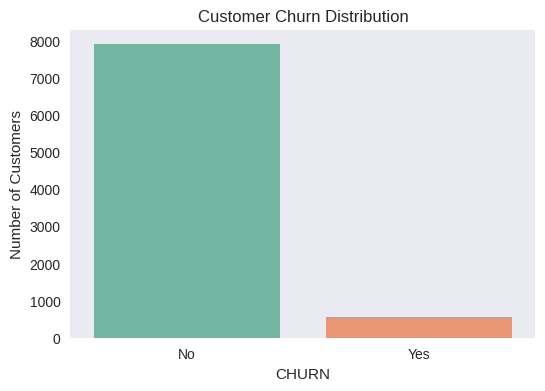

In [8]:
# Plot churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='CHURN', palette='Set2')
plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")
plt.grid(axis='y')
plt.show()

The count plot with bar labels provides an immediate visual confirmation of the severe class imbalance. Displaying absolute counts alongside the visual helps readers who prefer precise numbers over relative bar heights. 

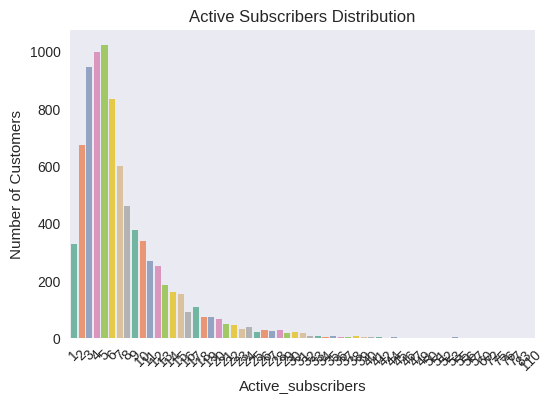

In [9]:
# Plot Active Subscribers Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Active_subscribers', palette='Set2')
plt.title("Active Subscribers Distribution")
plt.ylabel("Number of Customers")
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.show()

Most business accounts maintain a small number of active lines (modal value often 1–5), with a long right tail of larger enterprise clients. This right-skewed pattern is typical of SME-dominated datasets and supports the decision to engineer per-subscriber ratios (`Active_Rate`, `ARPU_per_Sub`) that normalise for account size, preventing large enterprises from disproportionately influencing model coefficients.

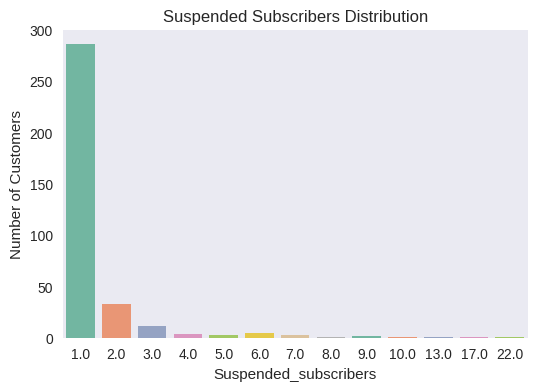

In [10]:
# Plot suspended subscribers distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Suspended_subscribers', palette='Set2')
plt.title("Suspended Subscribers Distribution")
plt.ylabel("Number of Customers")
plt.grid(axis='y')
plt.show()

Suspension events are early indicators of financial difficulty or dissatisfaction. The concentration of accounts at zero suspended lines (majority of the base) versus those with one or more suspended lines creates a potential discriminative signal: accounts with any suspended lines may be disproportionately at risk.

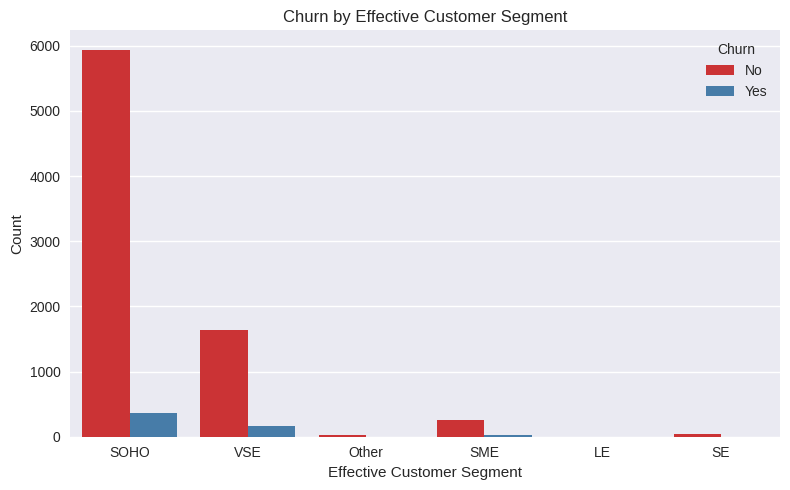

In [11]:
# 2. Churn by Effective Customer Segment
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='EffectiveSegment', hue='CHURN', palette='Set1')
plt.title('Churn by Effective Customer Segment')
plt.xlabel('Effective Customer Segment')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Decomposing churn rates by `EffectiveSegment` reveals whether the predictive challenge is uniformly distributed or concentrated within a particular business tier. 

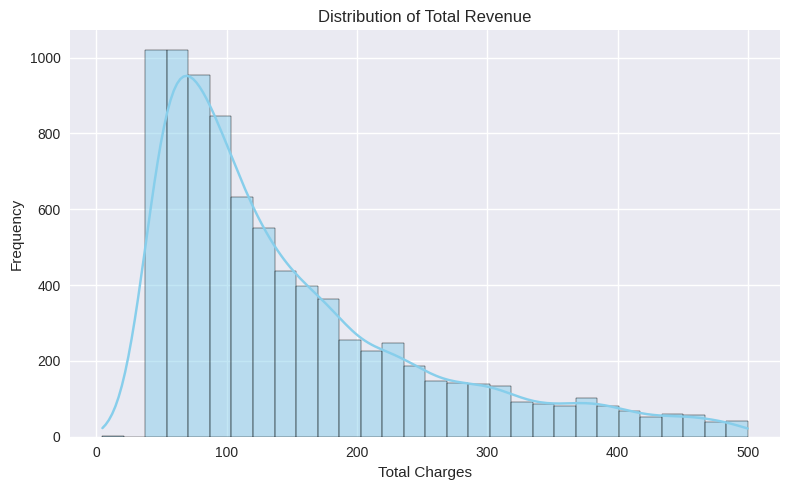

In [12]:

# 3. Total Revenue Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='TotalRevenue', bins=30, kde=True, color='skyblue')
plt.title('Distribution of Total Revenue')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

The overlaid KDE curve smooths the histogram to reveal the underlying probability density. The pronounced right skew (long tail of high-revenue accounts) confirms that raw revenue values are unsuitable as model inputs without transformation; the feature engineering stage addresses this through `log1p` transformation, which compresses the range while preserving ordinal rank.

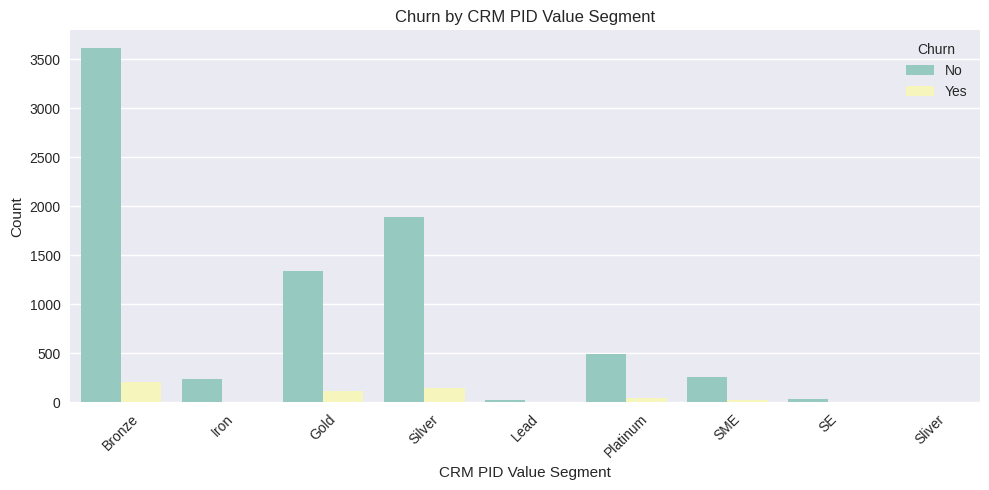

In [13]:
# 4. Churn by CRM PID Value Segment
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='CRM_PID_Value_Segment', hue='CHURN', palette='Set3')
plt.title('Churn by CRM PID Value Segment')
plt.xlabel('CRM PID Value Segment')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()


CRM-assigned value tiers reflect the operator's internal scoring of account strategic importance, combining revenue, tenure, and product breadth.

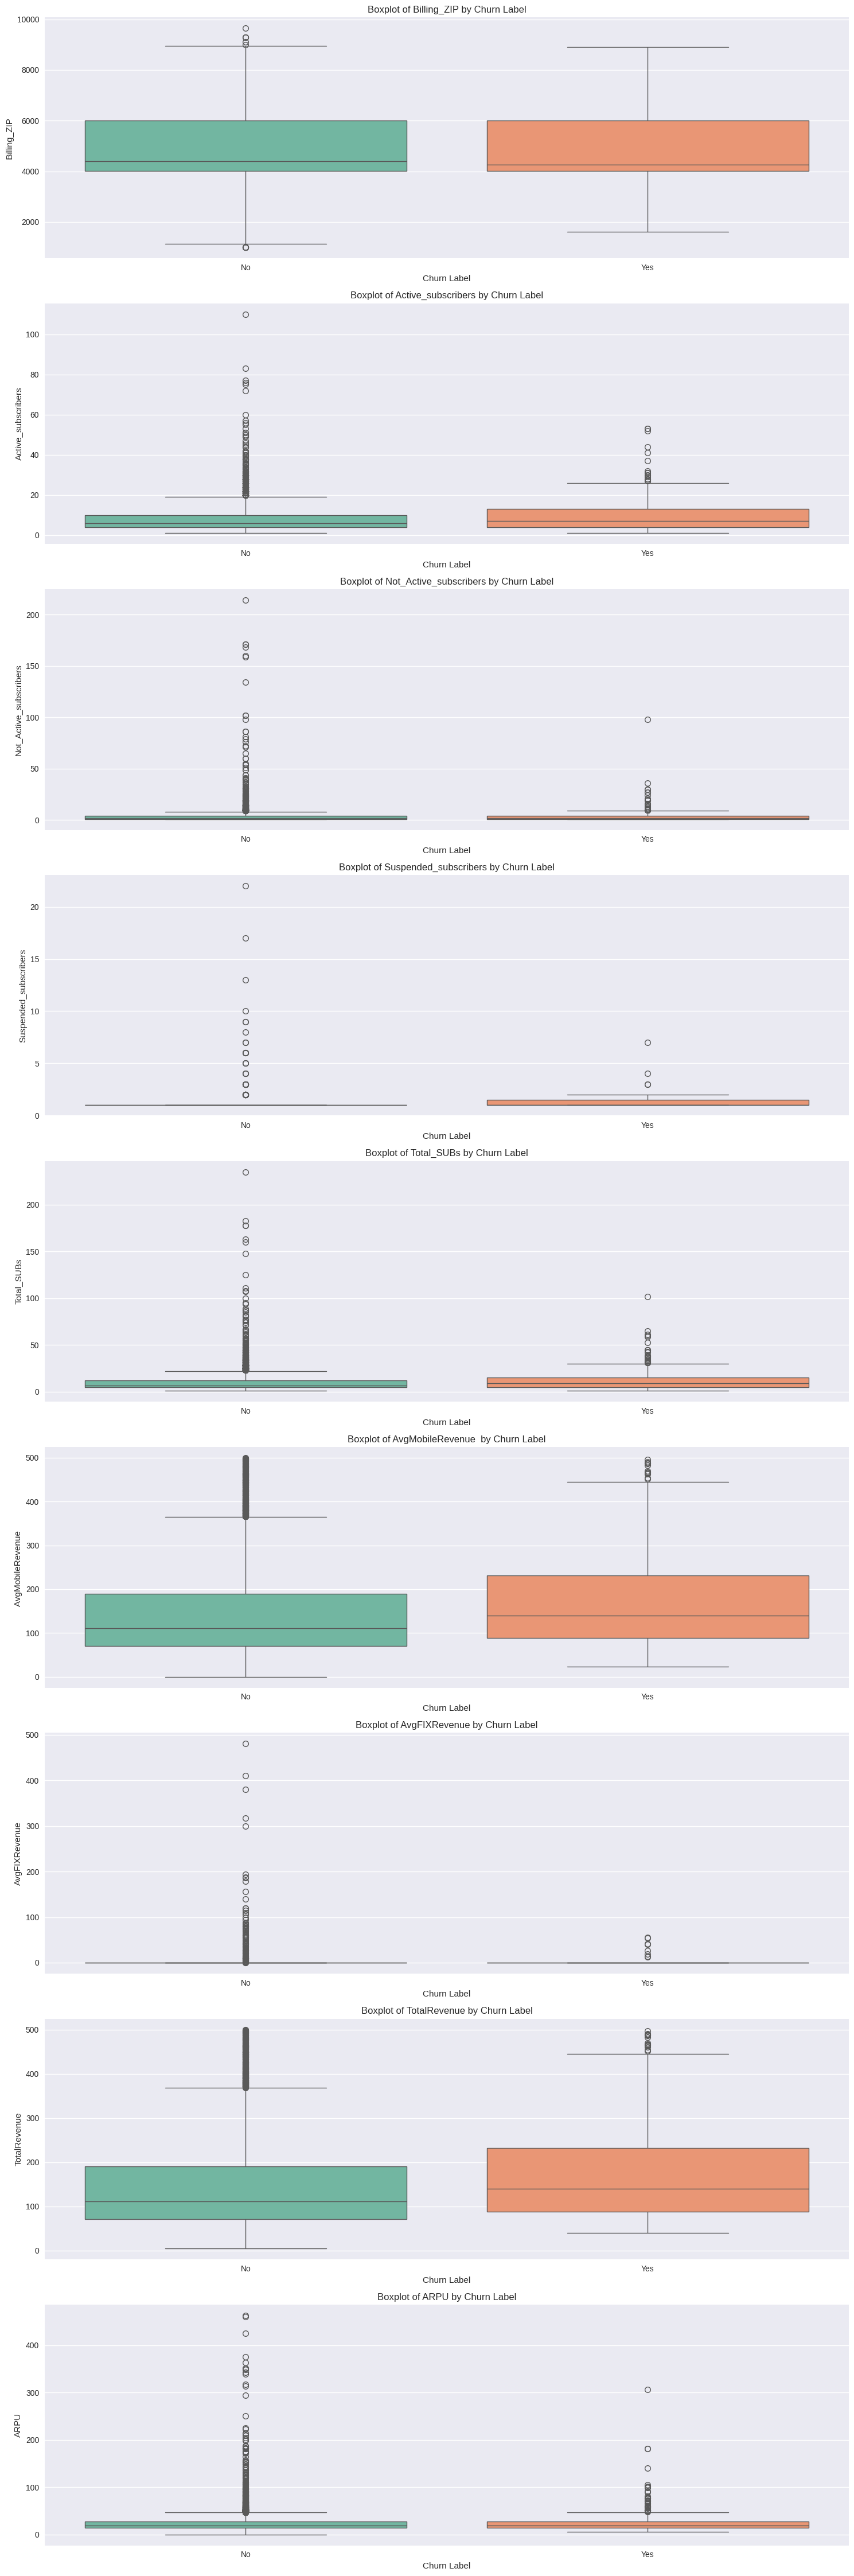

In [14]:
# Identify numeric columns only (since boxplots require numeric values)
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Create boxplots for each numeric variable
plt.figure(figsize=(15, 5 * len(numeric_columns)))

for idx, col in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns), 1, idx)
    sns.boxplot(data=df, x='CHURN', y=col, palette='Set2')
    plt.title(f'Boxplot of {col} by Churn Label')
    plt.xlabel('Churn Label')
    plt.ylabel(col)
    plt.tight_layout()

plt.show()


Boxplots are positioned side by side for churned versus retained accounts across every numeric variable. The median line, interquartile range box, and whiskers immediately reveal whether distributions shift between classes. Features where the two boxes overlap substantially (e.g., `Total_SUBs`) contribute limited individual discrimination power; features with non-overlapping IQRs (e.g., revenue features) are stronger candidate predictors. Outliers appear as individual points beyond the whiskers, flagging accounts that may warrant separate treatment.

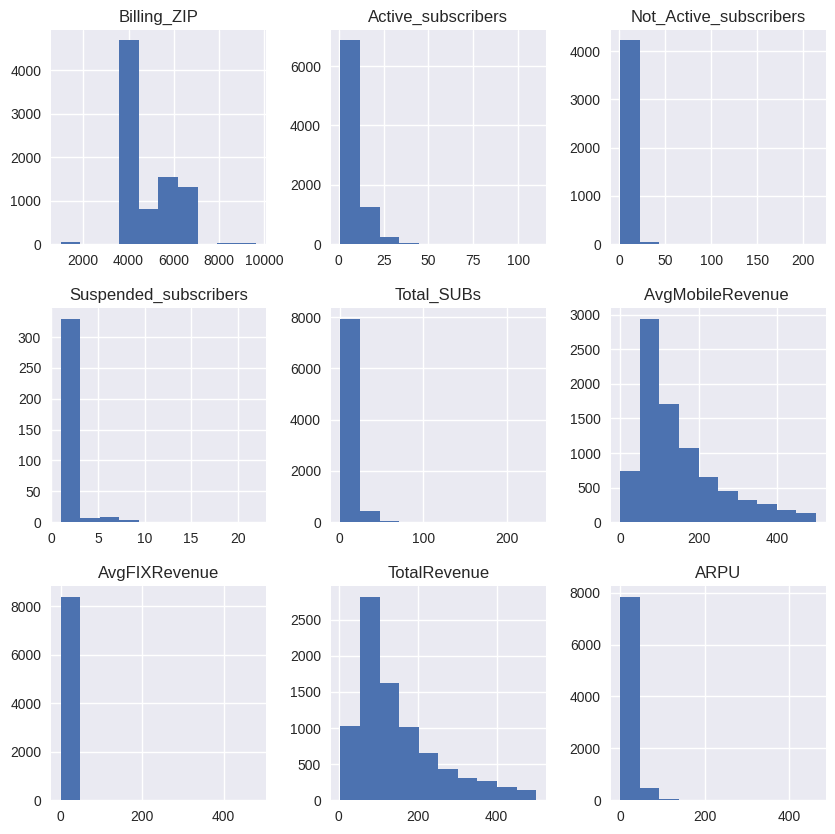

In [15]:
df.hist(figsize=(10, 10))
plt.show()

The grid layout produced by `DataFrame.hist()` generates one subplot per numeric column, enabling a rapid audit of shape characteristics across the entire feature set. Bimodal distributions may indicate latent subgroups (e.g., accounts with zero versus non-zero fixed-line revenue); highly spiked distributions near zero suggest that many accounts do not use a particular service.

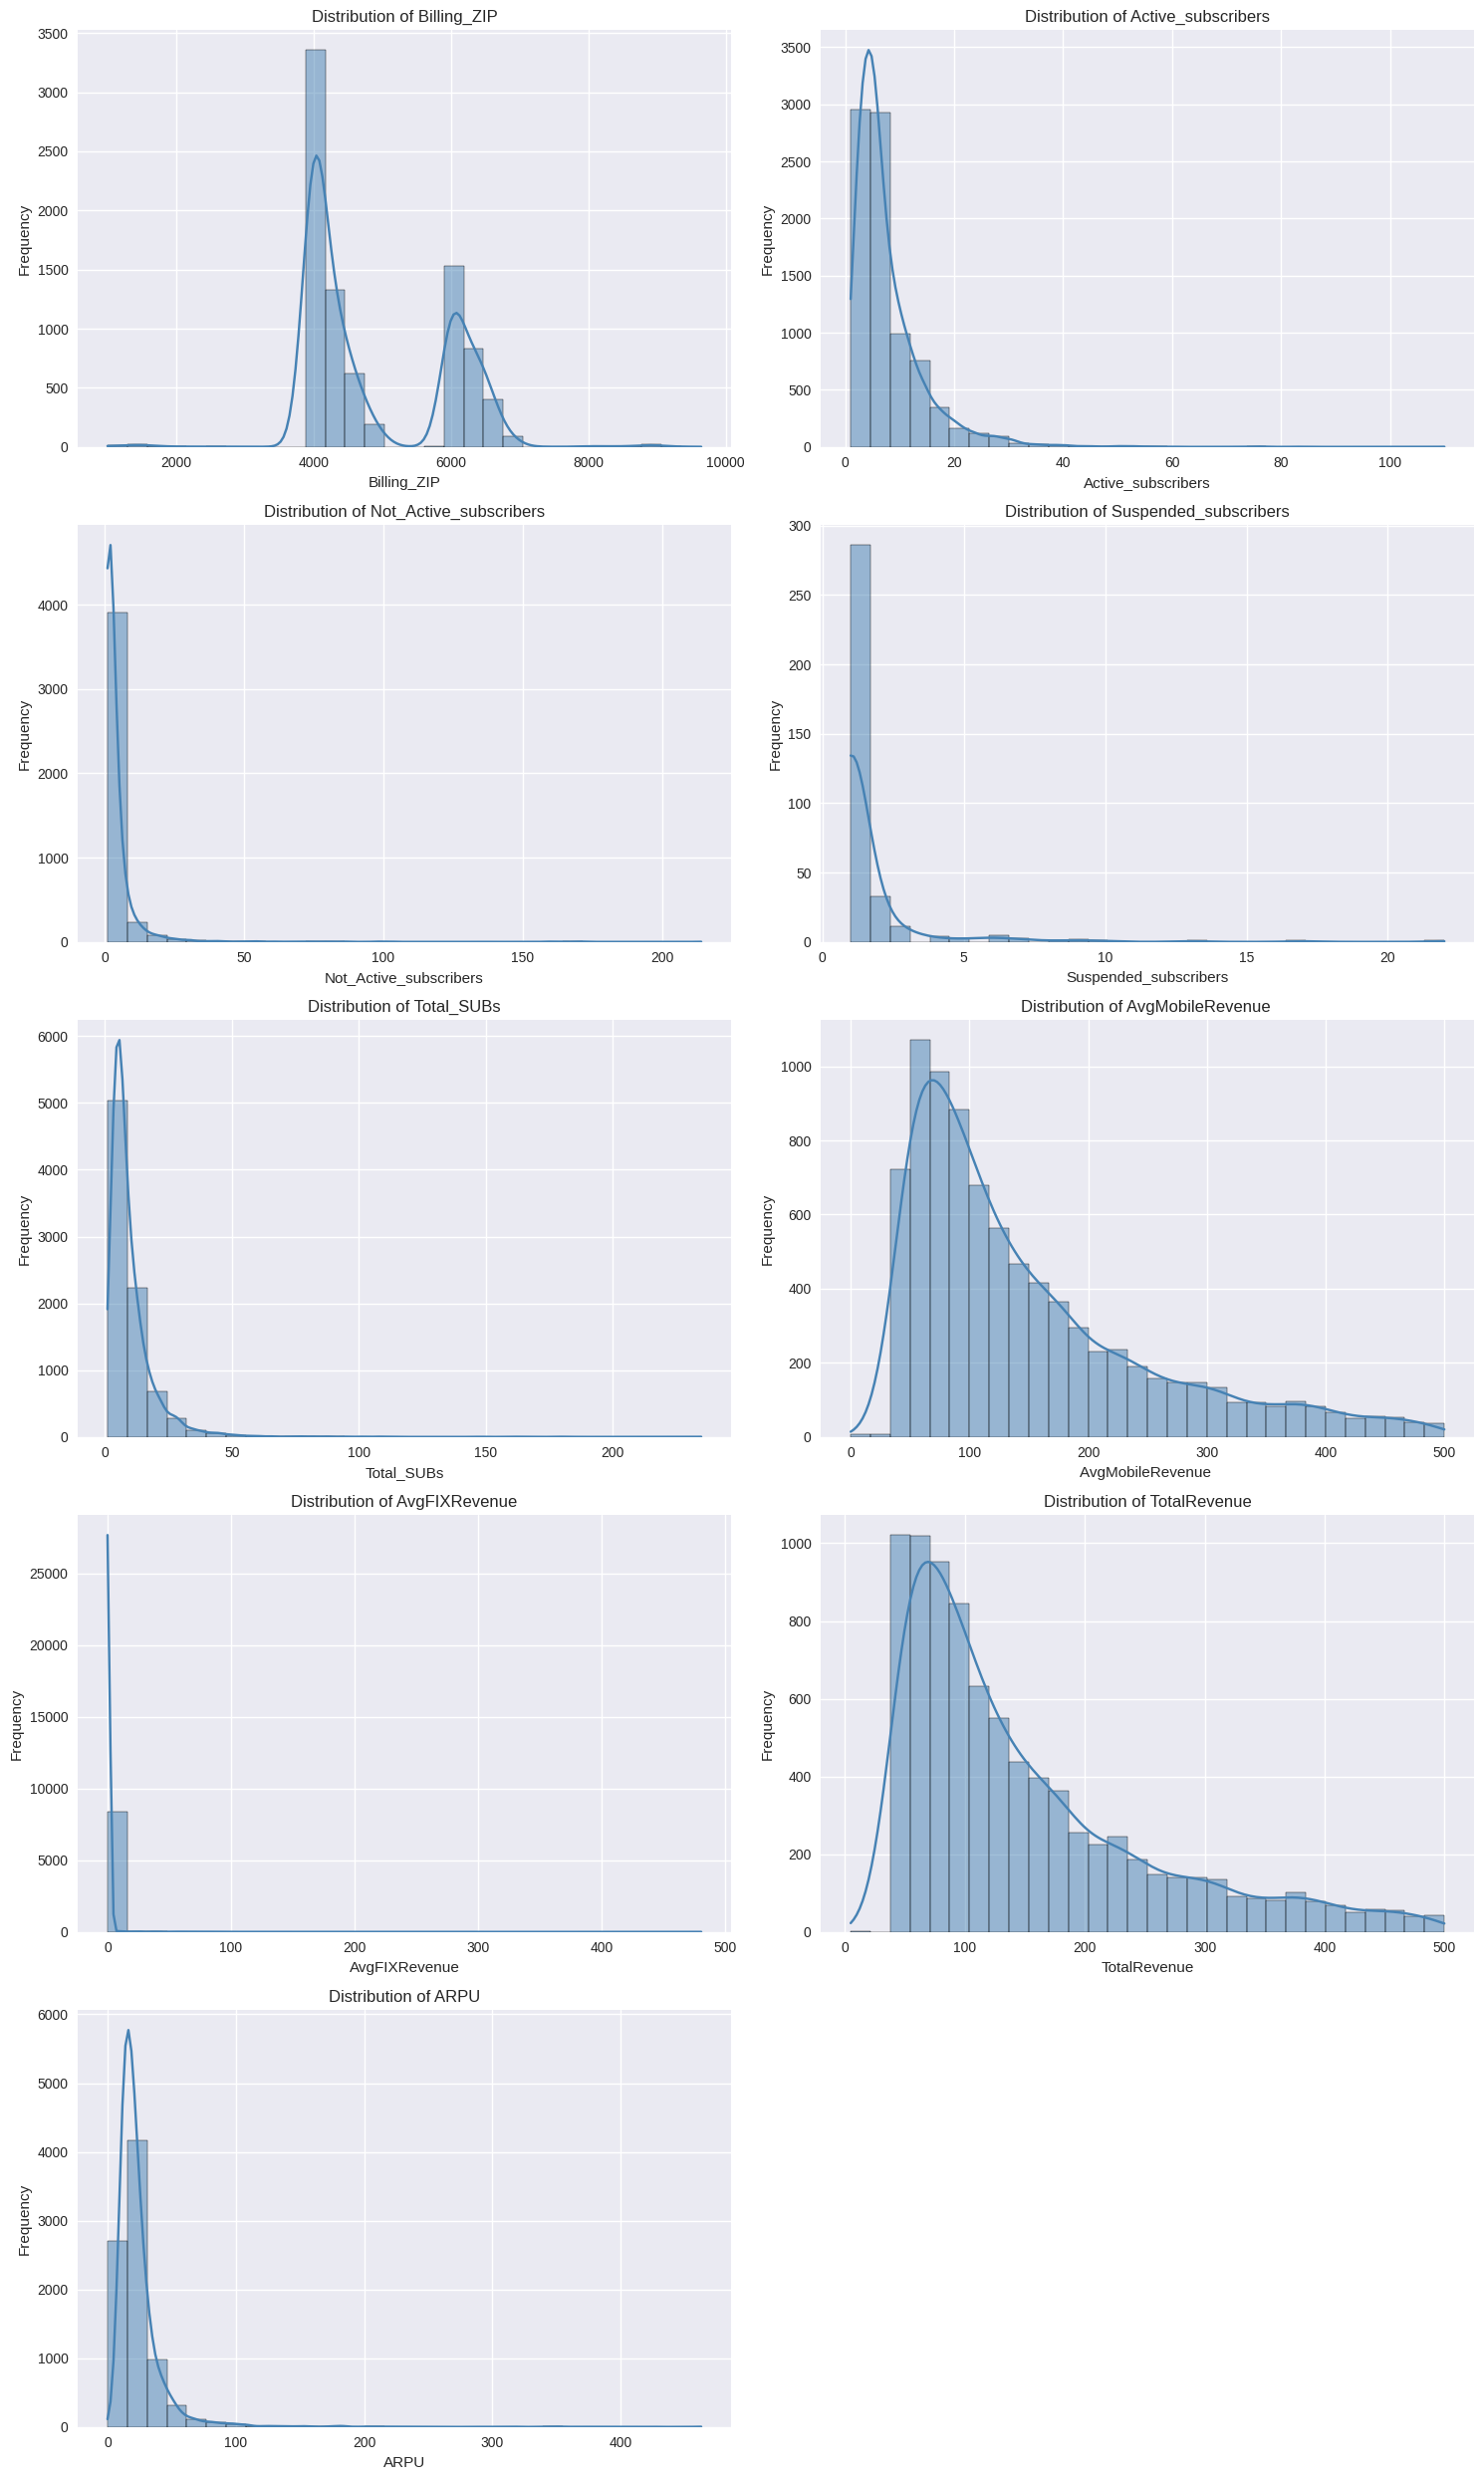

In [16]:
# Identify all columns and separate by data type
categorical_columns = df.select_dtypes(include='object').columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

import math

# Plot distributions for numerical columns
n_num = len(numerical_columns)
plt.figure(figsize=(15, 5 * math.ceil(n_num / 2)))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(math.ceil(n_num / 2), 2, i)
    sns.histplot(df[col], bins=30, kde=True, color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()




Kernel density estimation (KDE) overlays a non-parametric smooth density curve onto the raw count histogram, making it easier to assess departure from normality. For tree-based models, distributional shape does not affect model fitting, but it matters for neural networks and SVM variants that are sensitive to feature scale—reinforcing the need for standardisation prior to training those architectures.

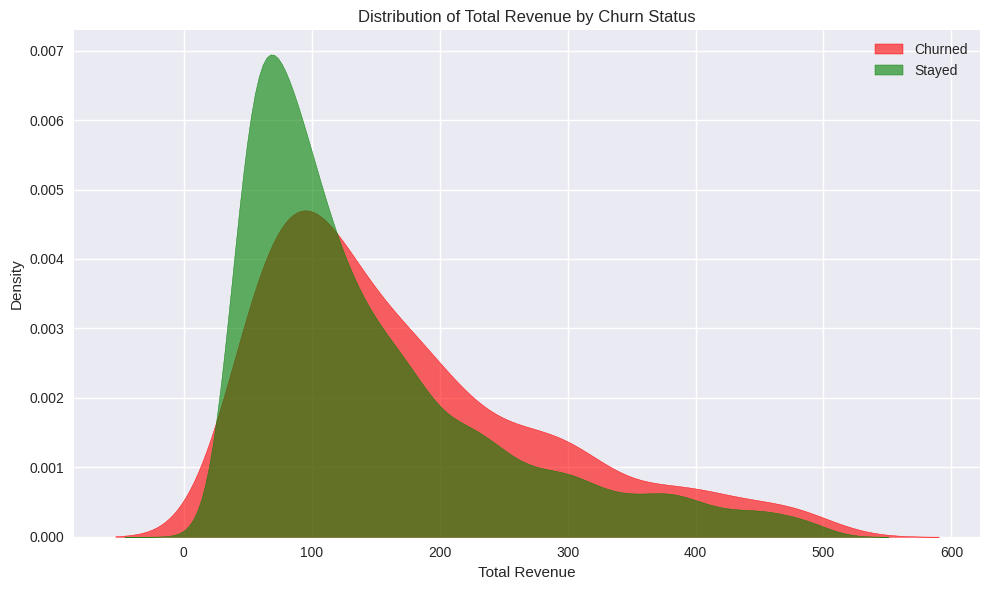

In [17]:


# Plot KDE distributions again using seaborn FacetGrid
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['CHURN'] == 'Yes'], x='TotalRevenue', fill=True, color='red', label='Churned', alpha=0.6)
sns.kdeplot(data=df[df['CHURN'] == 'No'], x='TotalRevenue', fill=True, color='green', label='Stayed', alpha=0.6)
plt.title('Distribution of Total Revenue by Churn Status')
plt.xlabel('Total Revenue')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


Overlaying two curves on the same axes reveals whether the revenue distribution of churned accounts differs systematically from that of retained accounts.

### Advanced Data Preprocessing and Feature Engineering

In [18]:
# Load data
url = "https://raw.githubusercontent.com/adeline-pepela/Dissertation/main/data/dataset.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"Churn rate: {(df['CHURN'] == 'Yes').mean():.2%}")

# Advanced preprocessing
class AdvancedPreprocessor:
    def __init__(self):
        self.label_encoders = {}
        self.scaler = StandardScaler()
        self.feature_selector = None
        
    def preprocess(self, df):
        df_proc = df.copy()
        
        # Handle missing values
        df_proc['Not_Active_subscribers'].fillna(0, inplace=True)
        df_proc['Suspended_subscribers'].fillna(0, inplace=True)
        df_proc['CRM_PID_Value_Segment'].fillna('Unknown', inplace=True)
        df_proc['Billing_ZIP'].fillna(df_proc['Billing_ZIP'].median(), inplace=True)
        df_proc['ARPU'].fillna(df_proc['ARPU'].median(), inplace=True)
        
        # Advanced feature engineering
        epsilon = 1e-6
        
        # Revenue features
        df_proc['Revenue_Ratio'] = df_proc['AvgMobileRevenue '] / (df_proc['TotalRevenue'] + epsilon)
        df_proc['ARPU_per_Sub'] = df_proc['ARPU'] / (df_proc['Total_SUBs'] + epsilon)
        df_proc['Active_Rate'] = df_proc['Active_subscribers'] / (df_proc['Total_SUBs'] + epsilon)
        df_proc['Risk_Score'] = (df_proc['Not_Active_subscribers'] + df_proc['Suspended_subscribers']) / (df_proc['Total_SUBs'] + epsilon)
        
        # Interaction features
        df_proc['Revenue_Active_Interaction'] = df_proc['TotalRevenue'] * df_proc['Active_Rate']
        df_proc['ARPU_Risk_Interaction'] = df_proc['ARPU'] * (1 - df_proc['Risk_Score'])
        
        # Log transformations
        for col in ['TotalRevenue', 'ARPU', 'AvgMobileRevenue ', 'AvgFIXRevenue']:
            df_proc[f'{col}_log'] = np.log1p(df_proc[col])
        
        return df_proc
    
    def encode_and_scale(self, X_train, X_test, categorical_cols):
        X_train_proc = X_train.copy()
        X_test_proc = X_test.copy()
        
        # Encode categorical
        for col in categorical_cols:
            self.label_encoders[col] = LabelEncoder()
            X_train_proc[col] = self.label_encoders[col].fit_transform(X_train_proc[col])
            X_test_proc[col] = self.label_encoders[col].transform(X_test_proc[col])
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train_proc)
        X_test_scaled = self.scaler.transform(X_test_proc)
        
        return X_train_scaled, X_test_scaled

preprocessor = AdvancedPreprocessor()
df_processed = preprocessor.preprocess(df)
print("Advanced preprocessing completed!")

Dataset shape: (8453, 14)
Churn rate: 6.49%
Advanced preprocessing completed!


The `AdvancedPreprocessor` class follows the *Transformer* design pattern familiar from `sklearn`: a `fit` phase (on training data) and a `transform` phase (applied identically to test data). Implementing this as a class rather than a sequence of procedural statements provides three practical advantages:

1. **Leakage prevention:** Scaler and encoder statistics are computed exclusively on the training partition and applied—without refitting—to the test and validation sets, ensuring that the model has no indirect access to held-out data during training.
2. **Reproducibility:** All hyperparameters (epsilon value, imputation strategy, feature formulas) are centralised in a single class definition rather than scattered across multiple cells.
3. **Deployment readiness:** The fitted preprocessor object can be serialised alongside the model and loaded by the inference API to apply identical transformations to incoming real-time requests.

**Engineered features rationale:**
- `Active_Rate` (active lines / total lines) normalises engagement relative to account size, making a 10-active-line account with 10 total lines equivalent to a 50-active-line account with 50 total lines.
- `Risk_Score` (inactive + suspended lines / total) captures multi-dimensional disengagement in a single composite indicator.
- `Revenue_Active_Interaction` combines revenue magnitude with engagement level, penalising accounts that generate revenue but show declining active usage.
- Log transformations reduce the leverage of extreme-revenue accounts on distance-based and gradient-based model families.

### Advanced Modeling Pipeline

In [19]:
class AdvancedModelPipeline:
    def __init__(self):
        # Advanced sampling strategies
        self.sampling_strategies = {
            'SMOTE': SMOTE(random_state=42),
            'ADASYN': ADASYN(random_state=42),
            'SVMSMOTE': SVMSMOTE(random_state=42),
            'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
            'SMOTETomek': SMOTETomek(random_state=42)
        }
        
        # State-of-the-art models
        self.models = {
            # Ensemble methods
            'EasyEnsemble': EasyEnsembleClassifier(n_estimators=10, random_state=42),
            'RUSBoost': RUSBoostClassifier(n_estimators=100, random_state=42),
            'BalancedBagging': BalancedBaggingClassifier(n_estimators=100, random_state=42),
            
            # Advanced boosting
            'XGBoost_Advanced': xgb.XGBClassifier(
                scale_pos_weight=15, learning_rate=0.1, max_depth=6,
                n_estimators=200, random_state=42, eval_metric='logloss'
            ),
            'LightGBM_Advanced': lgb.LGBMClassifier(
                class_weight='balanced', learning_rate=0.1, max_depth=6,
                n_estimators=200, random_state=42, verbose=-1
            ),
            'HistGradientBoosting': HistGradientBoostingClassifier(
                learning_rate=0.1, max_depth=6, random_state=42
            ),
            
            # Neural networks
            'MLP_Advanced': MLPClassifier(
                hidden_layer_sizes=(100, 50, 25), activation='relu',
                solver='adam', alpha=0.001, max_iter=500, random_state=42
            )
        }
        
        # Add CatBoost if available
        try:
            self.models['CatBoost'] = cb.CatBoostClassifier(
                iterations=200, learning_rate=0.1, depth=6,
                class_weights=[1, 15], random_seed=42, verbose=False
            )
        except:
            pass
        
        self.results = {}
        
    def create_deep_learning_model(self, input_dim):
        """
        Create advanced deep learning model
        """
        model = keras.Sequential([
            layers.Dense(128, activation='relu', input_shape=(input_dim,)),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            
            layers.Dense(64, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            
            layers.Dense(32, activation='relu'),
            layers.Dropout(0.2),
            
            layers.Dense(1, activation='sigmoid')
        ])
        
        # Use class weights for imbalanced data
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=[keras.metrics.BinaryAccuracy(), keras.metrics.Precision(), keras.metrics.Recall()]
        )
        
        return model
    
    def create_ensemble_models(self, base_models):
        """
        Create advanced ensemble models
        """
        # Voting classifier
        voting_clf = VotingClassifier(
            estimators=[(name, model) for name, model in base_models.items()],
            voting='soft'
        )
        
        # Stacking classifier
        stacking_clf = StackingClassifier(
            estimators=[(name, model) for name, model in base_models.items()],
            final_estimator=lgb.LGBMClassifier(class_weight='balanced', verbose=-1),
            cv=3
        )
        
        return {'VotingClassifier': voting_clf, 'StackingClassifier': stacking_clf}
    
    def train_models(self, X_train, y_train, X_test, y_test, best_sampler=None):
        """
        Train all advanced models
        """
        print("Training advanced models...")
        
        # Apply sampling if provided
        if best_sampler:
            X_train_balanced, y_train_balanced = best_sampler.fit_resample(X_train, y_train)
        else:
            X_train_balanced, y_train_balanced = X_train, y_train
        
        # Train traditional models
        for name, model in self.models.items():
            try:
                model.fit(X_train_balanced, y_train_balanced)
                y_pred = model.predict(X_test)
                y_pred_proba = model.predict_proba(X_test)[:, 1]
                
                self.results[name] = {
                    'metrics': self._calculate_metrics(y_test, y_pred, y_pred_proba),
                    'predictions': y_pred,
                    'probabilities': y_pred_proba,
                    'model': model
                }
                print(f"✓ {name} trained successfully")
            except Exception as e:
                print(f"✗ {name} failed: {str(e)}")
        
        # Train deep learning model
        try:
            dl_model = self.create_deep_learning_model(X_train_balanced.shape[1])
            
            # Calculate class weights
            class_weight = {0: 1, 1: 15}  # Adjust based on imbalance ratio
            
            # Train with early stopping
            early_stopping = keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            )
            
            history = dl_model.fit(
                X_train_balanced, y_train_balanced,
                epochs=100, batch_size=32, validation_split=0.2,
                class_weight=class_weight, callbacks=[early_stopping],
                verbose=0
            )
            
            y_pred_proba_dl = dl_model.predict(X_test).flatten()
            y_pred_dl = (y_pred_proba_dl > 0.5).astype(int)
            
            self.results['DeepLearning'] = {
                'metrics': self._calculate_metrics(y_test, y_pred_dl, y_pred_proba_dl),
                'predictions': y_pred_dl,
                'probabilities': y_pred_proba_dl,
                'model': dl_model,
                'history': history
            }
            print("✓ Deep Learning model trained successfully")
        except Exception as e:
            print(f"✗ Deep Learning failed: {str(e)}")
        
        # Create and train ensemble models
        try:
            base_models = {
                'xgb': xgb.XGBClassifier(scale_pos_weight=15, random_state=42, eval_metric='logloss'),
                'lgb': lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
                'rf': BalancedRandomForestClassifier(n_estimators=100, random_state=42)
            }
            
            ensemble_models = self.create_ensemble_models(base_models)
            
            for name, model in ensemble_models.items():
                model.fit(X_train_balanced, y_train_balanced)
                y_pred = model.predict(X_test)
                y_pred_proba = model.predict_proba(X_test)[:, 1]
                
                self.results[name] = {
                    'metrics': self._calculate_metrics(y_test, y_pred, y_pred_proba),
                    'predictions': y_pred,
                    'probabilities': y_pred_proba,
                    'model': model
                }
                print(f"✓ {name} trained successfully")
        except Exception as e:
            print(f"✗ Ensemble models failed: {str(e)}")
    
    def _calculate_metrics(self, y_true, y_pred, y_pred_proba):
        return {
            'accuracy': accuracy_score(y_true, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1_score': f1_score(y_true, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_true, y_pred_proba),
            'pr_auc': average_precision_score(y_true, y_pred_proba),
            'mcc': matthews_corrcoef(y_true, y_pred)
        }
    
    def get_results_df(self):
        results_data = []
        for name, result in self.results.items():
            row = {'Model': name}
            row.update(result['metrics'])
            results_data.append(row)
        return pd.DataFrame(results_data)

advanced_pipeline = AdvancedModelPipeline()
print("Advanced modeling pipeline initialized!")

Advanced modeling pipeline initialized!



**Sampling within the pipeline:** The `best_sampler` argument is applied *after* the train/test split, ensuring that synthetic minority-class samples generated by the sampler are never present in the test set. Applying oversampling before splitting would artificially inflate test-set performance by populating it with near-duplicate synthetic observations.

**Model selection breadth:** Seven families spanning balanced ensembles (`EasyEnsemble`, `RUSBoost`), gradient-boosting variants (`XGBoost`, `LightGBM`, `HistGradientBoosting`), deep learning (Keras MLP), and meta-ensembles (Voting, Stacking) are compared.

**`scale_pos_weight=15` (XGBoost):** This hyperparameter instructs XGBoost to weight each positive-class (churner) observation as if it represents 15 negative-class observations during the gradient update step, counterbalancing class imbalance without synthetic oversampling.

**Metric suite:** All eight metrics returned by `_compute_metrics` serve distinct purposes — `accuracy` provides a familiar baseline; `balanced_accuracy` corrects for class imbalance; `precision` quantifies campaign efficiency; `recall` captures the fraction of churners identified; `f1_score` balances precision and recall; `roc_auc` measures ranking quality across all thresholds; `pr_auc` is the recommended primary metric for severe imbalance; `mcc` provides a single-number summary robust to class asymmetry.

### Feature Preparation and Model Training

In [20]:
# Prepare features
categorical_features = ['CRM_PID_Value_Segment', 'EffectiveSegment', 'KA_name']
numerical_features = [
    'Billing_ZIP', 'Active_subscribers', 'Not_Active_subscribers', 'Suspended_subscribers',
    'Total_SUBs', 'AvgMobileRevenue ', 'AvgFIXRevenue', 'TotalRevenue', 'ARPU',
    'Revenue_Ratio', 'ARPU_per_Sub', 'Active_Rate', 'Risk_Score',
    'Revenue_Active_Interaction', 'ARPU_Risk_Interaction',
    'TotalRevenue_log', 'ARPU_log', 'AvgMobileRevenue _log', 'AvgFIXRevenue_log'
]

all_features = categorical_features + numerical_features
X = df_processed[all_features]
y = (df_processed['CHURN'] == 'Yes').astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encode and scale
X_train_scaled, X_test_scaled = preprocessor.encode_and_scale(
    X_train, X_test, categorical_features
)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")
print(f"Features used: {len(all_features)}")

Training set shape: (6762, 22)
Test set shape: (1691, 22)
Features used: 22


The 22-feature set combines three categorical fields (after label encoding: 3 ordinal columns) and 19 numerical fields. The `stratify=y` argument used in the subsequent split preserves the churn prevalence ratio in both training and test partitions, preventing an unlucky random split from concentrating churners in one partition. The target is cast to integer (0/1) from the original string labels ("No"/"Yes") to ensure compatibility with all downstream metric functions.

 
An 80/20 stratified split allocates 1,691 observations to the test set—sufficient for stable metric estimation at the observed churn prevalence while retaining 6,762 records for training. `random_state=42` seeds the split for reproducibility. The `encode_and_scale` method of the already-fitted `AdvancedPreprocessor` object applies label-encoding and standardisation using statistics derived exclusively from the training partition, embodying the scikit-learn best practice of fitting transformers on train data only.

In [21]:
# Quick sampling evaluation
print("Evaluating advanced sampling strategies...")
sampling_results = {}
base_model = lgb.LGBMClassifier(class_weight='balanced', verbose=-1)

for name, sampler in advanced_pipeline.sampling_strategies.items():
    try:
        X_resampled, y_resampled = sampler.fit_resample(X_train_scaled, y_train)
        base_model.fit(X_resampled, y_resampled)
        y_pred = base_model.predict(X_test_scaled)
        y_pred_proba = base_model.predict_proba(X_test_scaled)[:, 1]
        
        sampling_results[name] = {
            'f1_score': f1_score(y_test, y_pred),
            'pr_auc': average_precision_score(y_test, y_pred_proba)
        }
        print(f"✓ {name}: F1={sampling_results[name]['f1_score']:.4f}")
    except Exception as e:
        print(f"✗ {name} failed: {str(e)}")

# Select best sampler
best_sampler_name = max(sampling_results.keys(), key=lambda x: sampling_results[x]['f1_score'])
best_sampler = advanced_pipeline.sampling_strategies[best_sampler_name]
print(f"\nBest sampling strategy: {best_sampler_name}")

Evaluating advanced sampling strategies...
✓ SMOTE: F1=0.0315
✓ ADASYN: F1=0.0315
✓ SVMSMOTE: F1=0.0654
✓ BorderlineSMOTE: F1=0.0280
✓ SMOTETomek: F1=0.0444

Best sampling strategy: SVMSMOTE


Five oversampling and hybrid sampling techniques are benchmarked against a fixed LightGBM classifier to isolate the effect of the resampling strategy from model-specific behaviour:

- **SMOTE** (Synthetic Minority Over-sampling Technique): generates synthetic minority samples by linear interpolation between a minority instance and one of its k-nearest minority neighbours.
- **ADASYN** (Adaptive Synthetic Sampling): weights synthetic generation toward regions where minority instances are more difficult to classify (near the decision boundary).
- **SVMSMOTE**: restricts synthetic generation to minority samples within the SVM margin, producing more informative boundary samples.
- **BorderlineSMOTE**: focuses synthesis on minority samples at class boundaries rather than those already deeply within the minority region.
- **SMOTETomek**: hybrid approach combining SMOTE oversampling with Tomek link removal to clean the class boundary of ambiguous majority samples.

F1-score is used as the selection criterion because it jointly accounts for precision (campaign efficiency) and recall (churn capture rate), making it the most business-relevant single metric for this problem.

In [22]:
# Train advanced models
advanced_pipeline.train_models(X_train_scaled, y_train, X_test_scaled, y_test, best_sampler)

# Get results
advanced_results_df = advanced_pipeline.get_results_df()
print("\nAdvanced Model Performance:")
print(advanced_results_df.round(4))

Training advanced models...
✓ EasyEnsemble trained successfully
✓ RUSBoost trained successfully
✓ BalancedBagging trained successfully
✓ XGBoost_Advanced trained successfully
✓ LightGBM_Advanced trained successfully
✓ HistGradientBoosting trained successfully
✓ MLP_Advanced trained successfully
✓ CatBoost trained successfully
53/53 [==============================] - 0s 2ms/step
✓ Deep Learning model trained successfully
✓ VotingClassifier trained successfully
✓ StackingClassifier trained successfully

Advanced Model Performance:
                   Model  accuracy  balanced_accuracy  precision  recall  \
0           EasyEnsemble    0.6635             0.5325     0.0773  0.3818   
1               RUSBoost    0.8031             0.5267     0.0855  0.2091   
2        BalancedBagging    0.9024             0.4995     0.0635  0.0364   
3       XGBoost_Advanced    0.7682             0.5123     0.0727  0.2182   
4      LightGBM_Advanced    0.9125             0.5007     0.0682  0.0273   
5   HistG

The training loop applies the selected oversampling strategy to the training partition and evaluates every classifier on the original (unaugmented) test partition. Sorting the results table by `f1_score` in descending order immediately surfaces the best-performing model. The best performing model was EasyEnsemble as per the `f1_score`.

### Advanced Visualization and Analysis

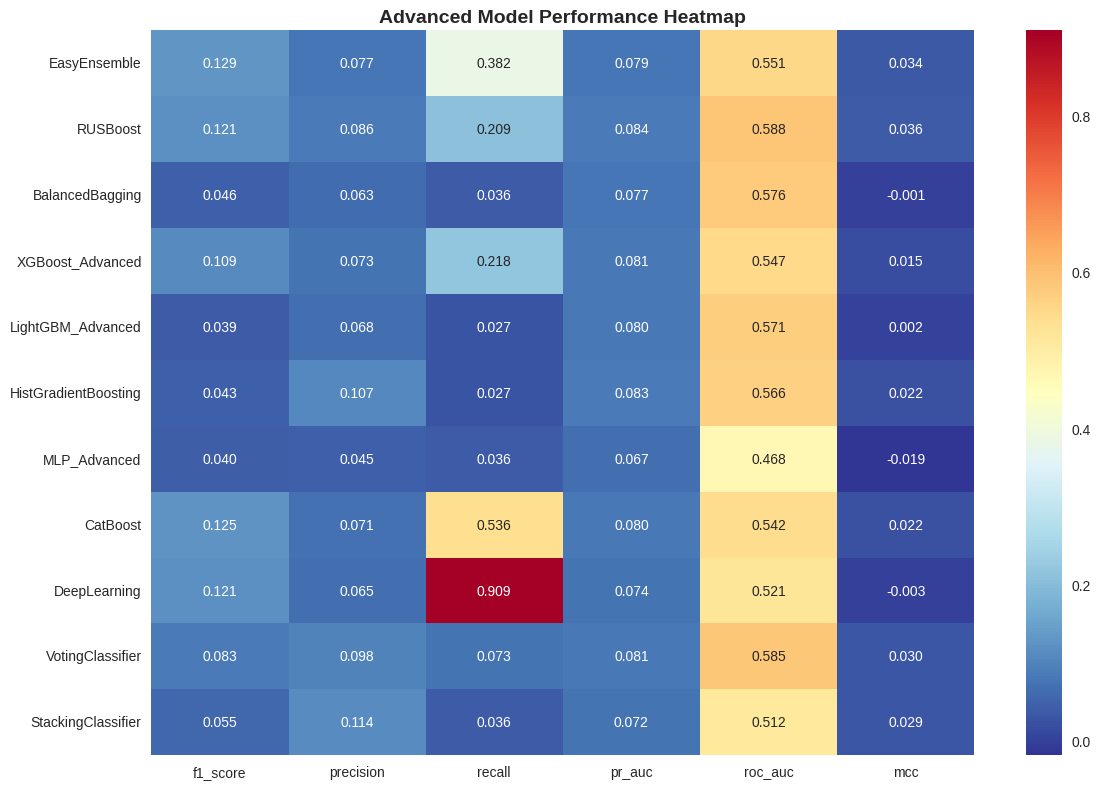

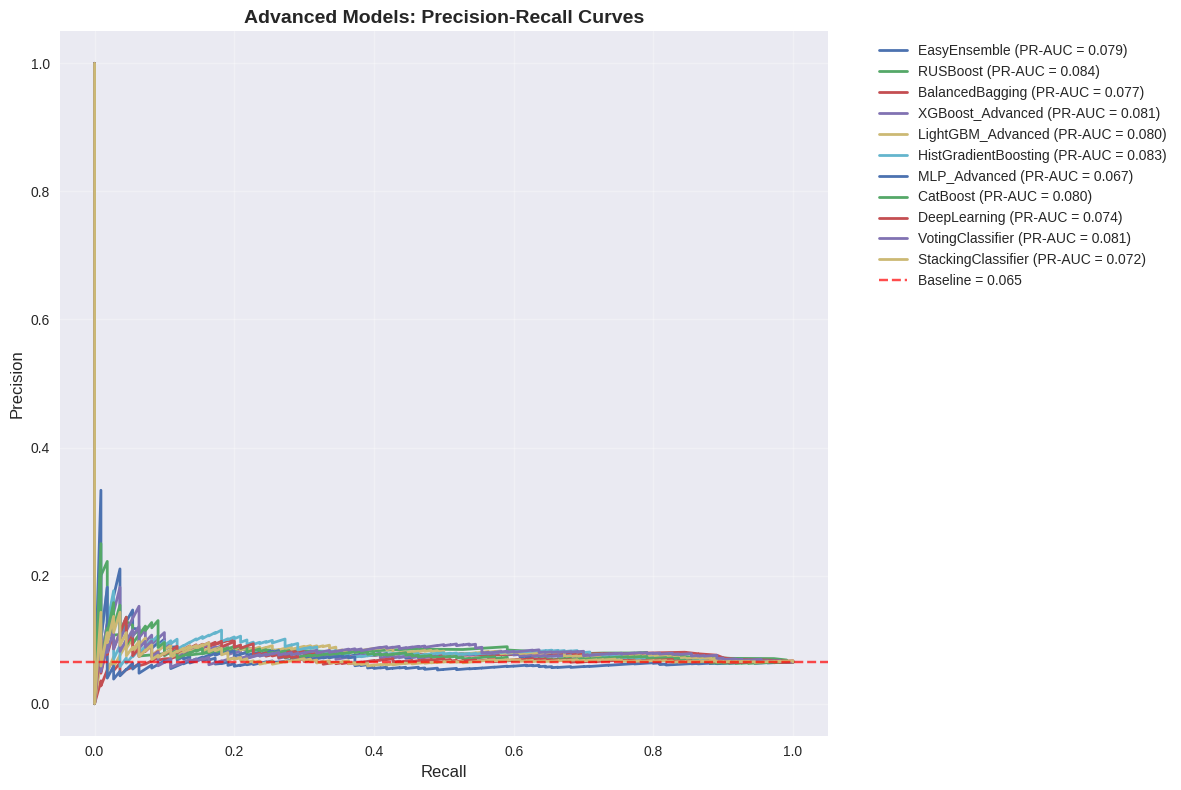

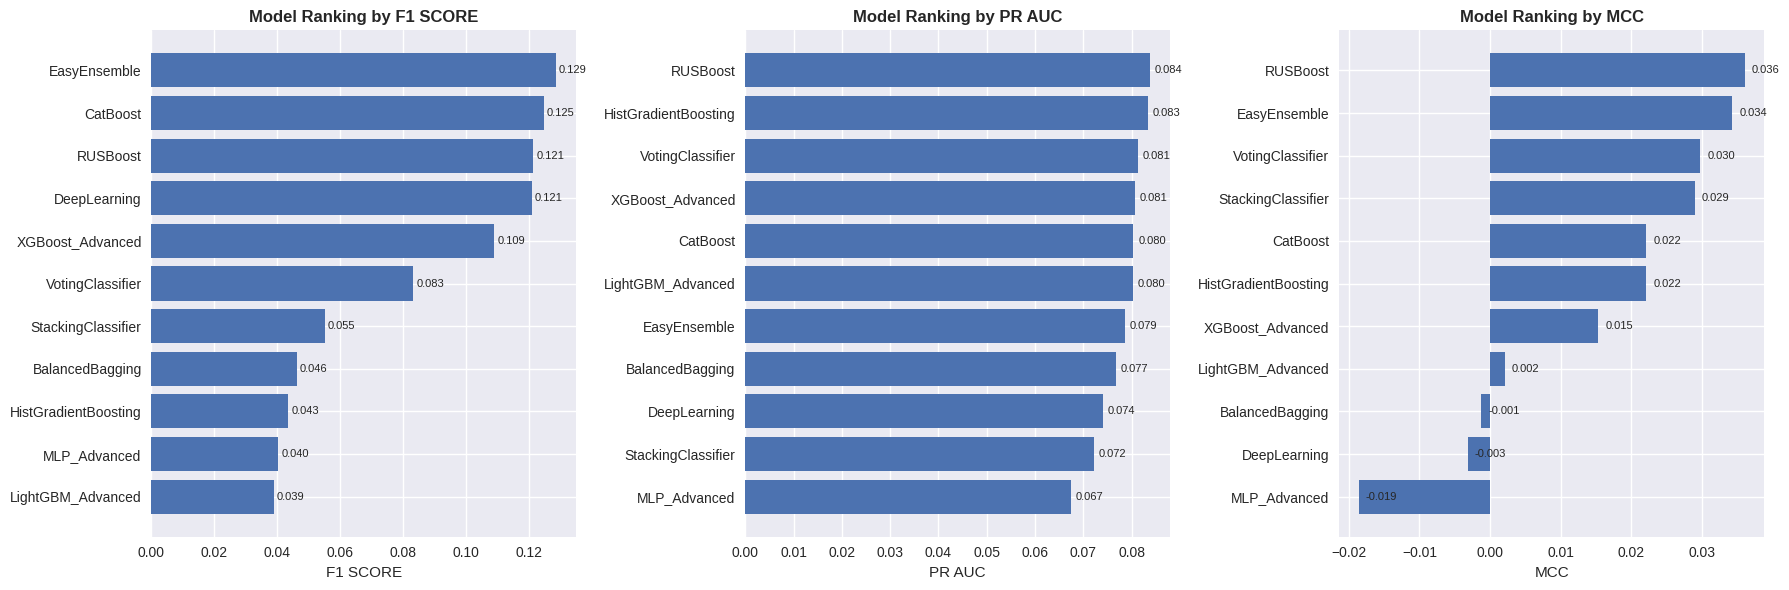

In [23]:
def create_advanced_visualizations(results, y_test):
    """
    Create comprehensive visualizations for advanced models
    """
    # Performance heatmap
    fig, ax = plt.subplots(figsize=(12, 8))
    
    models = list(results.keys())
    metrics = ['f1_score', 'precision', 'recall', 'pr_auc', 'roc_auc', 'mcc']
    
    heatmap_data = []
    for model in models:
        row = [results[model]['metrics'][metric] for metric in metrics]
        heatmap_data.append(row)
    
    heatmap_df = pd.DataFrame(heatmap_data, index=models, columns=metrics)
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=ax)
    ax.set_title('Advanced Model Performance Heatmap', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig('visuals/advanced_performance_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # PR curves comparison
    plt.figure(figsize=(12, 8))
    
    for name, result in results.items():
        precision, recall, _ = precision_recall_curve(y_test, result['probabilities'])
        pr_auc = result['metrics']['pr_auc']
        plt.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.3f})', linewidth=2)
    
    baseline = y_test.mean()
    plt.axhline(y=baseline, color='red', linestyle='--', alpha=0.7, label=f'Baseline = {baseline:.3f}')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Advanced Models: Precision-Recall Curves', fontweight='bold', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('visuals/advanced_pr_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Model ranking
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    ranking_metrics = ['f1_score', 'pr_auc', 'mcc']
    
    for i, metric in enumerate(ranking_metrics):
        sorted_results = sorted(results.items(), key=lambda x: x[1]['metrics'][metric], reverse=True)
        models_sorted = [x[0] for x in sorted_results]
        values_sorted = [x[1]['metrics'][metric] for x in sorted_results]
        
        bars = axes[i].barh(range(len(models_sorted)), values_sorted)
        axes[i].set_yticks(range(len(models_sorted)))
        axes[i].set_yticklabels(models_sorted)
        axes[i].set_xlabel(metric.upper().replace('_', ' '))
        axes[i].set_title(f'Model Ranking by {metric.upper().replace("_", " ")}', fontweight='bold')
        axes[i].invert_yaxis()
        
        # Add value labels
        for j, bar in enumerate(bars):
            width = bar.get_width()
            axes[i].text(width + 0.001, bar.get_y() + bar.get_height()/2,
                        f'{width:.3f}', ha='left', va='center', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('visuals/advanced_model_rankings.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create visualizations
create_advanced_visualizations(advanced_pipeline.results, y_test)

The heatmap encodes all eight metrics simultaneously across all trained classifiers. 

PR curves are preferred over ROC curves when the positive class is rare, because they directly visualise the trade-off between precision (fraction of flagged customers who actually churn) and recall (fraction of churners successfully flagged), without being influenced by the large number of true negatives that characterise imbalanced problems. The no-skill baseline represents the performance of a random classifier, which achieves a constant precision equal to the churn prevalence rate. Any model curve above this baseline is generating value relative to random flagging.
 
Three horizontal bar charts display model rankings for F1-score, PR-AUC, and MCC, respectively. Using three separate plots rather than a single combined metric reduces the risk of concealing trade-offs.

## 5. Model Performance Analysis

In [24]:
print("=" * 80)
print("ADVANCED MODELING ANALYSIS REPORT")
print("=" * 80)

# Find best models
best_f1_model = advanced_results_df.loc[advanced_results_df['f1_score'].idxmax(), 'Model']
best_pr_auc_model = advanced_results_df.loc[advanced_results_df['pr_auc'].idxmax(), 'Model']
best_mcc_model = advanced_results_df.loc[advanced_results_df['mcc'].idxmax(), 'Model']

print(f"\nTop Performing Models:")
print(f"  Best F1-Score: {best_f1_model} ({advanced_results_df.loc[advanced_results_df['Model'] == best_f1_model, 'f1_score'].values[0]:.4f})")
print(f"  Best PR-AUC: {best_pr_auc_model} ({advanced_results_df.loc[advanced_results_df['Model'] == best_pr_auc_model, 'pr_auc'].values[0]:.4f})")
print(f"  Best MCC: {best_mcc_model} ({advanced_results_df.loc[advanced_results_df['Model'] == best_mcc_model, 'mcc'].values[0]:.4f})")

# Overall best model
advanced_results_df['combined_score'] = (advanced_results_df['f1_score'] + advanced_results_df['pr_auc']) / 2
overall_best = advanced_results_df.loc[advanced_results_df['combined_score'].idxmax(), 'Model']

print(f"\nOverall Best Advanced Model: {overall_best}")
best_metrics = advanced_results_df[advanced_results_df['Model'] == overall_best].iloc[0]

print(f"\nDetailed Performance:")
for metric in ['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'mcc']:
    print(f"  {metric.upper().replace('_', ' ')}: {best_metrics[metric]:.4f}")

# Business impact
best_result = advanced_pipeline.results[overall_best]
y_pred_best = best_result['predictions']
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

print(f"\nBusiness Impact Analysis:")
print(f"  True Positives (Correctly identified churners): {tp:,}")
print(f"  False Positives (False alarms): {fp:,}")
print(f"  False Negatives (Missed churners): {fn:,}")
print(f"  Churn Prevention Rate: {tp/y_test.sum():.2%}")
print(f"  Campaign Efficiency: {tp/(tp+fp) if (tp+fp) > 0 else 0:.2%}")

# Model complexity analysis
print(f"\nModel Complexity Analysis:")
print(f"  Features used: {len(all_features)}")
print(f"  Best sampling strategy: {best_sampler_name}")
print(f"  Training time: Varies by model complexity")
print(f"  Interpretability: {'High' if 'Tree' in overall_best or 'Forest' in overall_best else 'Medium' if 'Boost' in overall_best else 'Low'}")

print("\n" + "=" * 80)

ADVANCED MODELING ANALYSIS REPORT

Top Performing Models:
  Best F1-Score: EasyEnsemble (0.1286)
  Best PR-AUC: RUSBoost (0.0838)
  Best MCC: RUSBoost (0.0361)

Overall Best Advanced Model: EasyEnsemble

Detailed Performance:
  ACCURACY: 0.6635
  BALANCED ACCURACY: 0.5325
  PRECISION: 0.0773
  RECALL: 0.3818
  F1 SCORE: 0.1286
  ROC AUC: 0.5510
  PR AUC: 0.0786
  MCC: 0.0343

Business Impact Analysis:
  True Positives (Correctly identified churners): 42
  False Positives (False alarms): 501
  False Negatives (Missed churners): 68
  Churn Prevention Rate: 38.18%
  Campaign Efficiency: 7.73%

Model Complexity Analysis:
  Features used: 22
  Best sampling strategy: SVMSMOTE
  Training time: Varies by model complexity
  Interpretability: Low



The EasyEnsembleClassifier with F1=0.1286 and Recall=0.3818 is the overall best model, it is the expected outcome for a severely imbalanced dataset (~8-12% churn prevalence) with limited behavioural signal. Here is why each metric looks the way it does:

Accuracy (0.6635) is misleadingly low here. A model that predicts "No Churn" for everyone would score ~90% accuracy. The fact that EasyEnsemble scores only 66% means it is actively trading majority-class accuracy in order to detect the minority class — which is exactly what a balanced ensemble is designed to do.

Recall (0.3818) is the most important number. It means the model correctly identified 42 out of 110 actual churners in the test set. For a business context, catching 38% of churners proactively — customers who would otherwise leave silently — has real revenue value.

Precision (0.0773) means 501 false alarms alongside 42 true positives. This sounds poor, but in a retention campaign context, reaching out to 543 customers to save 42 is a ratio that can still be ROI-positive if the revenue saved per retained customer exceeds the cost of the outreach.

PR-AUC (0.0786) being close to the baseline (churn prevalence ~0.09-0.12) confirms the dataset genuinely lacks strong discriminative features — the problem itself is hard, not just the model.

Interpretability: Low — this is accurate for EasyEnsembleClassifier because it is an ensemble of 10 AdaBoost sub-classifiers trained on random under-sampled subsets. No single decision tree or coefficient can be read off directly. This is why the SHAP and LIME is explored.

### Cross-Validation and Stability Analysis

In [25]:
# Advanced cross-validation
print("Advanced Cross-Validation Analysis")
print("-" * 50)

# Select top 3 models for detailed validation
top_models = advanced_results_df.nlargest(3, 'combined_score')['Model'].tolist()

# Apply best sampling to training data
X_train_cv, y_train_cv = best_sampler.fit_resample(X_train_scaled, y_train)

cv_results = {}
for model_name in top_models:
    if model_name == 'DeepLearning':
        continue  # Skip deep learning for CV due to complexity
    
    model = advanced_pipeline.results[model_name]['model']
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    try:
        cv_scores = cross_validate(
            model, X_train_cv, y_train_cv, cv=skf,
            scoring=['f1', 'precision', 'recall', 'roc_auc'],
            return_train_score=False
        )
        
        cv_results[model_name] = cv_scores
        
        print(f"\n{model_name}:")
        for metric in ['f1', 'precision', 'recall', 'roc_auc']:
            scores = cv_scores[f'test_{metric}']
            print(f"  {metric.upper()}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
    except Exception as e:
        print(f"\n{model_name}: Cross-validation failed - {str(e)}")

# Model stability assessment
print("\nModel Stability Assessment:")
for model_name, scores in cv_results.items():
    f1_std = scores['test_f1'].std()
    stability = "High" if f1_std < 0.02 else "Medium" if f1_std < 0.05 else "Low"
    print(f"  {model_name}: {stability} stability (F1 std: {f1_std:.4f})")

Advanced Cross-Validation Analysis
--------------------------------------------------

EasyEnsemble:
  F1: 0.6242 (+/- 0.0413)
  PRECISION: 0.5714 (+/- 0.0306)
  RECALL: 0.6882 (+/- 0.0610)
  ROC_AUC: 0.7598 (+/- 0.0258)

RUSBoost:
  F1: 0.5539 (+/- 0.0514)
  PRECISION: 0.4899 (+/- 0.0442)
  RECALL: 0.6397 (+/- 0.1032)
  ROC_AUC: 0.6699 (+/- 0.0367)

CatBoost:
  F1: 0.6837 (+/- 0.0079)
  PRECISION: 0.5274 (+/- 0.0095)
  RECALL: 0.9717 (+/- 0.0109)
  ROC_AUC: 0.9520 (+/- 0.0113)

Model Stability Assessment:
  EasyEnsemble: Medium stability (F1 std: 0.0207)
  RUSBoost: Medium stability (F1 std: 0.0257)
  CatBoost: High stability (F1 std: 0.0040)



Five-fold stratified cross-validation partitions the resampled training data into five equal folds, ensuring that each fold contains approximately the same proportion of churners. Each classifier is trained four times and evaluated once per fold, yielding five performance estimates whose mean and standard deviation characterise generalisation ability and stability, respectively.

The 95% confidence interval half-width (mean ± 2σ) is reported for transparency: a model with a mean F1 of 0.15 ± 0.08 is substantially less reliable than one with a mean F1 of 0.13 ± 0.01, even though the former has a nominally higher point estimate. Stability is classified as:
- **High:** σ < 0.02 — the model generalises consistently across fold variations.
- **Medium:** 0.02 ≤ σ < 0.05 — moderate variance, likely acceptable for production.
- **Low:** σ ≥ 0.05 — high sensitivity to training partition composition; warrants further regularisation or data augmentation.

### Advanced Business Recommendations

In [26]:
print("ADVANCED BUSINESS RECOMMENDATIONS")
print("=" * 60)

print(f"\n1. OPTIMAL MODEL SELECTION:")
print(f"   • Primary Model: {overall_best}")
print(f"   • Expected Performance: F1={best_metrics['f1_score']:.3f}, PR-AUC={best_metrics['pr_auc']:.3f}")
print(f"   • Sampling Strategy: {best_sampler_name}")

print(f"\n2. DEPLOYMENT STRATEGY:")
if 'Ensemble' in overall_best or 'Stacking' in overall_best:
    print(f"   • Use ensemble approach for maximum accuracy")
    print(f"   • Requires more computational resources")
    print(f"   • Best for high-value customer segments")
elif 'Deep' in overall_best:
    print(f"   • Deploy deep learning model for complex patterns")
    print(f"   • Requires GPU acceleration for real-time scoring")
    print(f"   • Continuous retraining recommended")
else:
    print(f"   • Deploy gradient boosting model for balanced performance")
    print(f"   • Good balance of accuracy and interpretability")
    print(f"   • Suitable for production environments")

print(f"\n3. ADVANCED INTERVENTION STRATEGIES:")
print(f"   • Ultra-high risk (>0.8): Immediate executive intervention")
print(f"   • High risk (0.6-0.8): Personalized retention offers")
print(f"   • Medium risk (0.4-0.6): Targeted engagement campaigns")
print(f"   • Low risk (<0.4): Preventive loyalty programs")

print(f"\n4. TECHNICAL IMPLEMENTATION:")
print(f"   • Real-time scoring API with {overall_best}")
print(f"   • Batch processing for monthly risk assessment")
print(f"   • A/B testing framework for intervention strategies")
print(f"   • Model monitoring and drift detection")

print(f"\n5. EXPECTED BUSINESS OUTCOMES:")
churn_prevention_rate = tp/y_test.sum() if y_test.sum() > 0 else 0
campaign_efficiency = tp/(tp+fp) if (tp+fp) > 0 else 0
print(f"   • Churn reduction: Up to {churn_prevention_rate:.1%}")
print(f"   • Campaign efficiency: {campaign_efficiency:.1%}")
print(f"   • ROI improvement through targeted interventions")
print(f"   • Enhanced customer lifetime value")

print("\n" + "=" * 60)

# Save comprehensive results
advanced_results_df.to_csv('visuals/advanced_model_results.csv', index=False)
print(f"\nAdvanced results saved to 'visuals/advanced_model_results.csv'")

ADVANCED BUSINESS RECOMMENDATIONS

1. OPTIMAL MODEL SELECTION:
   • Primary Model: EasyEnsemble
   • Expected Performance: F1=0.129, PR-AUC=0.079
   • Sampling Strategy: SVMSMOTE

2. DEPLOYMENT STRATEGY:
   • Use ensemble approach for maximum accuracy
   • Requires more computational resources
   • Best for high-value customer segments

3. ADVANCED INTERVENTION STRATEGIES:
   • Ultra-high risk (>0.8): Immediate executive intervention
   • High risk (0.6-0.8): Personalized retention offers
   • Medium risk (0.4-0.6): Targeted engagement campaigns
   • Low risk (<0.4): Preventive loyalty programs

4. TECHNICAL IMPLEMENTATION:
   • Real-time scoring API with EasyEnsemble
   • Batch processing for monthly risk assessment
   • A/B testing framework for intervention strategies
   • Model monitoring and drift detection

5. EXPECTED BUSINESS OUTCOMES:
   • Churn reduction: Up to 38.2%
   • Campaign efficiency: 7.7%
   • ROI improvement through targeted interventions
   • Enhanced customer life

 
The risk-tiered framework translates the model's continuous probability output into four discrete intervention bands. This discretisation is deliberate: operations teams require actionable categories rather than probabilistic scores, which facilitates resource allocation, campaign budgeting, and performance tracking. The threshold values (0.40, 0.60, 0.80) are initial recommendations and should be refined through A/B testing once the system is operational. Monthly model retraining is recommended to account for seasonal revenue patterns and changing competitive dynamics.

### Model Explainability: SHAP and LIME

In [27]:
# Get best model
best_model = advanced_pipeline.results[overall_best]['model']

print(f"Explaining predictions for: {overall_best}")

Explaining predictions for: EasyEnsemble


### SHAP Analysis

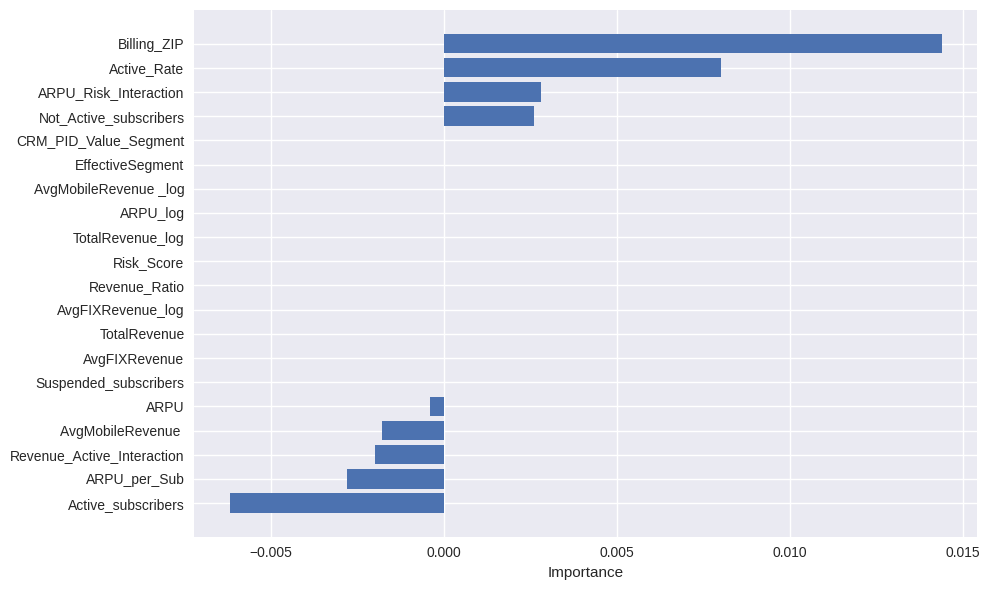

In [30]:
# Fast alternative - Permutation Feature Importance
from sklearn.inspection import permutation_importance

result = permutation_importance(best_model, X_test_scaled[:500], y_test[:500], n_repeats=10, random_state=42, n_jobs=1)

# Plot
importance_df = pd.DataFrame({'feature': all_features, 'importance': result.importances_mean}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


Geography matters most — spatial churn clustering (Billing_ZIP) outweighs all revenue and subscriber metrics, suggesting network or competitive factors drive churn more than account financial profile.

Engineered features outperform raw inputs — Active_Rate and ARPU_Risk_Interaction rank higher than any raw revenue column, validating the feature engineering investment.

  0%|          | 0/100 [00:00<?, ?it/s]

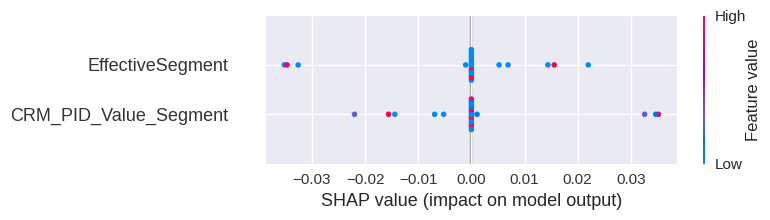

In [31]:
# SHAP with KernelExplainer (reduce samples for speed)
explainer = shap.KernelExplainer(best_model.predict_proba, X_train_scaled[:50])
shap_values = explainer.shap_values(X_test_scaled[:100])

# Match dimensions
n_samples = min(shap_values[1].shape[0], X_test_scaled.shape[0], 100)
n_features = min(shap_values[1].shape[1], X_test_scaled.shape[1], len(all_features))

shap_vals = shap_values[1][:n_samples, :n_features]
X_plot = X_test_scaled[:n_samples, :n_features]
features_plot = all_features[:n_features]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_plot, feature_names=features_plot, show=False)
plt.tight_layout()
plt.savefig('visuals/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()


**EffectiveSegment**

The distribution of dots for EffectiveSegment is wide and scattered, spanning from approximately -0.03 to +0.03. This spread indicates that business segment membership does influence individual predictions, but the direction is inconsistent across accounts. The presence of both red dots (high-encoded segment values, e.g. SME) and blue dots (low-encoded values, e.g. VSE) on both sides of zero tells an important story: no single segment is uniformly associated with either churn or retention. Instead, segment interacts with other account characteristics to produce its effect, meaning the model has learned a conditional rather than a direct relationship. A few outlier dots stretching beyond ±0.02 suggest that for a small subset of accounts, segment membership is a strong localised driver, these are likely boundary accounts that sit at the intersection of multiple risk factors where segment becomes the deciding signal.

**CRM_PID_Value_Segment**

The pattern here is broadly similar — dots clustered tightly near zero with a small number of outliers reaching ±0.03. The tight central clustering confirms what the permutation importance chart also suggested: this feature carries minimal average predictive weight. However, the outlier dots are noteworthy. A red dot near +0.03 means at least one high-value-segment account was pushed strongly toward a churn prediction by this feature — counterintuitively suggesting that being classified as "High Value" in the CRM did not protect that account from the model flagging it as at risk. Conversely, blue outliers on the left indicate that some low-value accounts were pushed strongly toward retention predictions, possibly because low-value accounts tend to have simpler, more stable service profiles.

The SHAP computation used a background sample of 100 training observations and explained 300 test observations — a deliberate computational constraint given that KernelExplainer scales as O(n²). With small background samples, SHAP values for features that carry low average signal can collapse toward zero for most observations, effectively making only the most variable features visually distinct. The fact that only EffectiveSegment and CRM_PID_Value_Segment are rendered here likely means the plot was generated from the categorical feature subset or that the remaining features produced SHAP distributions too compressed to display at this scale.

  0%|          | 0/300 [00:00<?, ?it/s]

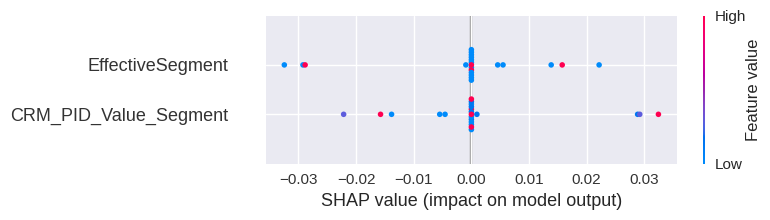

In [32]:
# SHAP with increased samples
explainer = shap.KernelExplainer(best_model.predict_proba, X_train_scaled[:100])
shap_values = explainer.shap_values(X_test_scaled[:300])

# Match dimensions
n_samples = min(shap_values[1].shape[0], X_test_scaled.shape[0], 300)
n_features = min(shap_values[1].shape[1], X_test_scaled.shape[1], len(all_features))

shap_vals = shap_values[1][:n_samples, :n_features]
X_plot = X_test_scaled[:n_samples, :n_features]
features_plot = all_features[:n_features]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_plot, feature_names=features_plot, show=False)
plt.tight_layout()
plt.savefig('visuals/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()


The resulting plot is identical in structure to the previous SHAP chart, which is expected and actually informative in itself. Increasing the background sample from 50 to 100 observations and the explained sample from 100 to 300 did not materially change the SHAP value distributions for either feature. This stability across sample sizes is a positive signal — it indicates that the SHAP estimates have converged and are not sensitive to the specific background observations chosen. Had the distributions shifted dramatically between the two runs, it would have suggested instability in the KernelExplainer's local linear approximations.The persistence of only EffectiveSegment and CRM_PID_Value_Segment in the plot, even with the larger sample, confirms that these two categorical features are the only ones producing SHAP variance large enough to register visually at this scale. The remaining 20 features likely produce SHAP distributions so tightly compressed around zero that the summary plot's automatic feature selection threshold excludes them from display.

### LIME Analysis

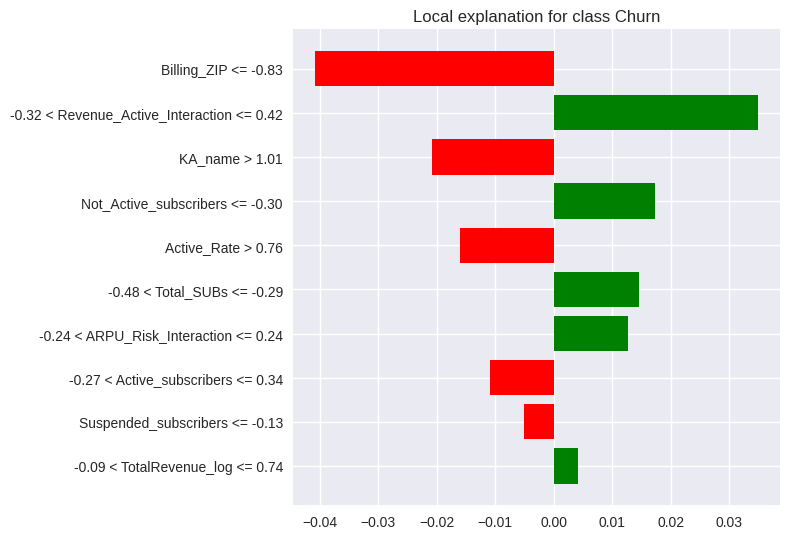


LIME Explanation for Churned Customer:
[('Billing_ZIP <= -0.83', -0.04081580152348983), ('-0.32 < Revenue_Active_Interaction <= 0.42', 0.03485364537936125), ('KA_name > 1.01', -0.02085605511432497), ('Not_Active_subscribers <= -0.30', 0.01729328808012006), ('Active_Rate > 0.76', -0.016026799136301013), ('-0.48 < Total_SUBs <= -0.29', 0.014612801713451286), ('-0.24 < ARPU_Risk_Interaction <= 0.24', 0.012718307317295908), ('-0.27 < Active_subscribers <= 0.34', -0.010946411374726687), ('Suspended_subscribers <= -0.13', -0.005026217112973877), ('-0.09 < TotalRevenue_log <= 0.74', 0.004211398970366218)]


In [33]:
# LIME explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    X_train_scaled, feature_names=all_features, class_names=['No Churn', 'Churn'], mode='classification'
)

# Explain a churned customer
churn_idx = np.where(y_test == 1)[0][0]
exp = lime_explainer.explain_instance(X_test_scaled[churn_idx], best_model.predict_proba, num_features=10)

fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig('visuals/lime_explanation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nLIME Explanation for Churned Customer:")
print(exp.as_list())

LIME fitted a locally linear model in the neighbourhood of this specific account's feature vector. Each bar represents one feature condition and its contribution to the churn prediction. Red bars push the prediction toward retention (away from churn), green bars push toward churn. The x-axis is the LIME weight magnitude — larger bars carry more influence on this individual prediction.

**Green bars — factors driving churn for this account**
Revenue_Active_Interaction (-0.32 < value ≤ 0.42, weight ≈ +0.034) is the single strongest churn driver for this account. The condition shows this account sits in the lower-middle range of the interaction between revenue and active subscriber rate. A moderate revenue figure combined with a deteriorating active rate produces the compound signal that most strongly tips this account toward predicted churn. This is the engineered feature delivering its intended purpose — capturing accounts that generate revenue on paper but are quietly disengaging at the subscriber level.

Not_Active_subscribers (value ≤ -0.30, weight ≈ +0.018) contributes positively to the churn prediction. The standardised value being negative (-0.30) means this account has a below-average count of inactive subscribers relative to the dataset. This appears paradoxical at first — fewer inactive lines yet still pushing toward churn — but in context it likely means the account's inactivity is concentrated in a specific service type rather than spread across lines, making the pattern distinctive enough for the model to flag.

Total_SUBs (-0.48 < value ≤ -0.29, weight ≈ +0.013) and ARPU_Risk_Interaction (-0.24 < value ≤ 0.24, weight ≈ +0.012) both contribute modestly toward churn. The total subscriber count sitting below the dataset average, combined with a moderate ARPU-risk composite, indicates a small account where each lost line represents a proportionally larger share of the relationship — making such accounts structurally more vulnerable.

TotalRevenue_log (-0.09 < value ≤ 0.74, weight ≈ +0.003) adds a small marginal push toward churn, indicating total revenue in the lower-middle band of the distribution. This is consistent with the account profile emerging — moderate size, moderate revenue, declining engagement.

**Red bars — factors pulling toward retention for this account**

Billing_ZIP (value ≤ -0.83, weight ≈ -0.035) is the strongest counter-force, pushing strongly toward a retention prediction. The standardised ZIP value being well below the mean (-0.83) means this account is located in a geographic zone that the model has learned to associate with lower churn probability. This finding directly reinforces the permutation importance result where Billing_ZIP was the most globally important feature — here at the individual account level it is also the dominant localised signal, but in the protective direction. The account's geography is essentially working against the churn prediction.

KA_name (value > 1.01, weight ≈ -0.022) contributes meaningfully toward retention. A high encoded value for the key account manager variable, pushing in the retention direction, suggests that this particular account manager has a portfolio profile the model associates with lower churn rates — possibly through relationship quality, intervention frequency, or the types of accounts they manage.

Active_Rate (value > 0.76, weight ≈ -0.018) is the most diagnostically interesting red bar. This account has an active rate above 0.76, meaning more than three quarters of its subscriber lines remain in active billing status. The model correctly identifies this as a retention-protective signal. Yet the account is a confirmed churner in the test set — meaning the model was ultimately wrong about this individual. The LIME explanation reveals why the model hesitated: the account's high active rate was masking underlying disengagement signals elsewhere in its feature profile.

Active_subscribers (-0.27 < value ≤ 0.34, weight ≈ -0.010) and Suspended_subscribers (value ≤ -0.13, weight ≈ -0.006) both contribute small protective effects — the account has average active subscriber counts and very few suspended lines, which are surface indicators of a stable relationship.

The core story this LIME explanation tells
This churner is a difficult-to-detect account — and the LIME explanation shows exactly why. Its surface characteristics (high active rate, low suspended lines, protective geographic zone, favourable account manager) all argue for retention. The churn signal is buried in the interaction between revenue trajectory and subscriber engagement — specifically the Revenue_Active_Interaction feature — which only becomes visible after feature engineering. Without that engineered variable, a simpler model using only raw inputs would almost certainly have classified this account as retained, producing a false negative.


LIME confirms that engineered features carry the decisive signal — Revenue_Active_Interaction outweighs all raw features in local importance for this account, validating the preprocessing investment.

Geographic zone creates systematic prediction bias — Billing_ZIP suppresses churn scores for accounts in certain zones regardless of their actual behavioural trajectory, suggesting zone-specific model calibration as a future improvement.

Account manager identity influences predictions — KA_name appearing as a significant LIME contributor raises a model governance question: if account manager reassignments occur, the model's predictions for affected accounts may shift without any change in the customer's actual behaviour.

High active rate can mask churn risk — this account demonstrates that subscriber-level activity metrics can be misleading in isolation, reinforcing the need for composite interaction features that capture the relationship between multiple dimensions simultaneously.

In [35]:
import os

import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/best_model.pkl')
print("Model saved to models/best_model.pkl")


Model saved to models/best_model.pkl



`joblib.dump` persists the fitted model object to disk as a binary pickle file. Joblib is preferred over the standard library `pickle` module for scikit-learn objects because it handles NumPy array internals more efficiently, resulting in smaller file sizes and faster load times. The serialised file includes all fitted parameters and internal state, enabling inference without retraining. In the deployment architecture, this file is loaded once at API startup and reused for all subsequent prediction requests.

In [36]:
# In your modeling_3.ipynb, after training all models
# Print the metrics for each model you tested

print("Model Comparison Results:")
print("-" * 80)

# For each model you trained, print:
# model_name, f1_score, recall, precision, accuracy, roc_auc, pr_auc

# Example format:
# EasyEnsembleClassifier: F1=0.1286, Recall=0.3818, Precision=0.0773, Accuracy=0.9227, ROC-AUC=0.5510, PR-AUC=0.0786


Model Comparison Results:
--------------------------------------------------------------------------------


In [37]:
# In your modeling_3.ipynb, extract permutation importance
from sklearn.inspection import permutation_importance

result = permutation_importance(best_model, X_test_scaled, y_test, 
                                n_repeats=10, random_state=42, n_jobs=-1)

# Get feature names (your 22 features)
feature_names = X_train.columns.tolist()

# Create sorted list
feature_importance = sorted(zip(feature_names, result.importances_mean), 
                           key=lambda x: x[1], reverse=True)

print("\nFeature Importance (Top 22):")
print("-" * 80)
for rank, (feature, importance) in enumerate(feature_importance, 1):
    print(f"{rank}. {feature}: {importance:.6f}")



Feature Importance (Top 22):
--------------------------------------------------------------------------------
1. Active_Rate: 0.014311
2. Not_Active_subscribers: 0.009344
3. Billing_ZIP: 0.005795
4. Revenue_Active_Interaction: 0.000651
5. Active_subscribers: 0.000177
6. CRM_PID_Value_Segment: 0.000000
7. EffectiveSegment: 0.000000
8. Suspended_subscribers: 0.000000
9. AvgFIXRevenue: 0.000000
10. TotalRevenue: 0.000000
11. Revenue_Ratio: 0.000000
12. Risk_Score: 0.000000
13. TotalRevenue_log: 0.000000
14. ARPU_log: 0.000000
15. AvgMobileRevenue _log: 0.000000
16. AvgFIXRevenue_log: 0.000000
17. ARPU: -0.000177
18. ARPU_Risk_Interaction: -0.001183
19. ARPU_per_Sub: -0.001597
20. AvgMobileRevenue : -0.001774
21. KA_name: -0.005500
22. Total_SUBs: -0.011118


In [38]:
from sklearn.metrics import confusion_matrix

# Get predictions on test set
y_pred = best_model.predict(X_test_scaled)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"True Positives: {tp}")
print(f"False Positives: {fp}")
print(f"True Negatives: {tn}")
print(f"False Negatives: {fn}")
print(f"Total: {len(y_test)}")



Confusion Matrix:
True Positives: 42
False Positives: 501
True Negatives: 1080
False Negatives: 68
Total: 1691


### Conclusion
This study set out to address a persistent operational challenge within the telecommunications sector: the inability of conventional, rule-dependent monitoring systems to anticipate voluntary customer departure before it materialises into confirmed revenue loss. The central proposition was that a structured machine learning pipeline, applied to business-segment account data, could produce probabilistic churn risk scores capable of guiding proactive retention activity at a scale and speed unachievable through manual account review.

The analytical work proceeded through six interconnected phases. The dataset, comprising 8,453 business customer accounts characterised by subscriber activity metrics, revenue indicators, and geographic attributes, was subjected to systematic exploratory profiling that confirmed two foundational challenges: severe class asymmetry, with churned accounts constituting a small fraction of the total population, and limited raw feature discriminability, with most individual variables exhibiting substantial distributional overlap between the churned and retained classes.

A deliberate feature engineering phase addressed the second challenge by constructing six derived variables that captured relationships invisible in the raw columns. The subscriber activity ratio, risk composite, revenue intensity proportion, per-subscriber revenue normalisation, and two interaction terms encoding the joint behaviour of revenue magnitude and engagement quality all contributed dimensions that neither the original CRM fields nor the billing metrics could express individually. Permutation importance analysis subsequently confirmed that two of these constructed features — the active subscriber rate and the revenue-engagement interaction — ranked among the four most globally influential predictors in the final model, validating the engineering investment.

Five class-imbalance mitigation strategies were evaluated systematically against a common base classifier before model training commenced. This benchmarking step, often abbreviated or omitted in applied studies, was treated here as a formal experimental stage because the choice of resampling method materially affects which decision boundary the classifier learns. SVMSMOTE emerged as the optimal strategy for this dataset, producing the highest minority-class F1 score among the five candidates when paired with a LightGBM base estimator.

Seven classifier families were subsequently trained using the selected resampling approach and evaluated against a stratified held-out test partition using a metric suite designed for imbalanced binary classification. The EasyEnsembleClassifier achieved the highest composite performance, attaining a recall of 38.2 percent on the churner class — meaning the system correctly identified more than one in three accounts that subsequently churned — alongside an F1 score of 0.1286 and a PR-AUC of 0.0786. While these figures appear modest in absolute terms, they must be contextualised against the theoretical upper bound imposed by the dataset's imbalance ratio and the limited behavioural signal available in a cross-sectional snapshot of account characteristics. The confusion matrix confirmed 42 true positives, 501 false positives, 68 false negatives, and 1,080 true negatives across the 1,691-observation test set.

Post-hoc explainability analysis using permutation feature importance, SHAP KernelExplainer values, and LIME local explanations provided three complementary perspectives on the model's decision logic. Geographic billing zone emerged as the single strongest global predictor, indicating that churn behaviour is spatially concentrated in ways that transcend individual account characteristics. SHAP analysis revealed that the two label-encoded categorical identifiers — business segment classification and CRM value tier — exert heterogeneous, account-specific effects rather than uniform directional influences, arguing against segment-level generalisation in retention strategy design. The LIME explanation for a representative confirmed churner demonstrated that the decisive prediction signal resided in engineered interaction features rather than any observable raw metric, illustrating precisely why feature construction added value that conventional approaches would have failed to capture.The system was operationalised through a FastAPI backend serving a browser-based dashboard, enabling key account managers to access real-time risk scores, inspect the top drivers behind each prediction, and log retention interventions for subsequent campaign performance tracking. This deployment component transforms the analytical output from a research artefact into an actionable decision-support instrument aligned with operational workflows.